In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact
import scienceplots
plt.style.use(['science','ieee'])
# plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False
plt.rcParams.update({
    "font.family": "serif",   
    "font.serif": ["Times"],  
    "font.size": 8,
    "lines.linewidth": 0.8,       
    "lines.markersize": 3,        
    "axes.linewidth": 0.5,        
    "xtick.major.width": 0.5,    
    "ytick.major.width": 0.5})         
plt.rcParams['patch.linewidth'] = 0.5
import matplotlib.patches as mpatches
from copy import deepcopy





/var/folders/kr/9njb39g95ks67mqh9tl6s2140000gn/T/ipykernel_8063/930999335.py:4: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact


# Load and adjust data

In [2]:
# load all data
input_allpopulation_noAS = pd.read_csv("data/input_allpopulation_noAS.csv")
input_selpopulation_noAS = pd.read_csv("data/input_selpopulation_noAS.csv")
input_sim1_noAS = pd.read_csv("data/input_selpopulation_sim1_noAS.csv")
input_sim2_noAS = pd.read_csv("data/input_selpopulation_sim2_noAS.csv")
input_sim3_noAS = pd.read_csv("data/input_selpopulation_sim3_noAS.csv")
input_sim4_noAS = pd.read_csv("data/input_selpopulation_sim4_noAS.csv")
output_allpopulation_noAS = pd.read_csv("data/output_allpopulation_noAS.csv")
output_selpopulation_noAS = pd.read_csv("data/output_selpopulation_noAS.csv")
output_sim1_noAS = pd.read_csv("data/output_selpopulation_sim1_noAS.csv")
output_sim2_noAS = pd.read_csv("data/output_selpopulation_sim2_noAS.csv")
output_sim3_noAS = pd.read_csv("data/output_selpopulation_sim3_noAS.csv")
output_sim4_noAS = pd.read_csv("data/output_selpopulation_sim4_noAS.csv")

input_allpopulation_AS = pd.read_csv("data/input_allpopulation_AS.csv")
input_selpopulation_AS = pd.read_csv("data/input_selpopulation_AS.csv")
input_sim1_AS = pd.read_csv("data/input_selpopulation_sim1_AS.csv")
input_sim2_AS = pd.read_csv("data/input_selpopulation_sim2_AS.csv")
input_sim3_AS = pd.read_csv("data/input_selpopulation_sim3_AS.csv")
input_sim4_AS = pd.read_csv("data/input_selpopulation_sim4_AS.csv")
output_allpopulation_AS = pd.read_csv("data/output_allpopulation_AS.csv")
output_selpopulation_AS = pd.read_csv("data/output_selpopulation_AS.csv")
output_sim1_AS = pd.read_csv("data/output_selpopulation_sim1_AS.csv")
output_sim2_AS = pd.read_csv("data/output_selpopulation_sim2_AS.csv")
output_sim3_AS = pd.read_csv("data/output_selpopulation_sim3_AS.csv")
output_sim4_AS = pd.read_csv("data/output_selpopulation_sim4_AS.csv")


all_input = [input_allpopulation_noAS, input_selpopulation_noAS, input_sim1_noAS, input_sim2_noAS, input_sim3_noAS, input_sim4_noAS,
             input_allpopulation_AS, input_selpopulation_AS, input_sim1_AS, input_sim2_AS, input_sim3_AS, input_sim4_AS]

all_output = [output_allpopulation_noAS, output_selpopulation_noAS, output_sim1_noAS, output_sim2_noAS, output_sim3_noAS, output_sim4_noAS,
              output_allpopulation_AS, output_selpopulation_AS, output_sim1_AS, output_sim2_AS, output_sim3_AS, output_sim4_AS]

In [3]:
# add CPP
for data in all_output:
    data["CPP"] = data["Pao_min"] - data["EDP_lv"]

# create fused dataset for simulations

input_allsimulations_noAS = pd.concat([input_sim1_noAS.sort_values(by="Patient_ID"), input_sim2_noAS.sort_values(by="Patient_ID"), input_sim3_noAS.sort_values(by="Patient_ID"), input_sim4_noAS.sort_values(by="Patient_ID")], ignore_index=True)
output_allsimulations_noAS = pd.concat([output_sim1_noAS.sort_values(by="Patient_ID"), output_sim2_noAS.sort_values(by="Patient_ID"), output_sim3_noAS.sort_values(by="Patient_ID"), output_sim4_noAS.sort_values(by="Patient_ID")], ignore_index=True)
input_allsimulations_AS = pd.concat([input_sim1_AS.sort_values(by="Patient_ID"), input_sim2_AS.sort_values(by="Patient_ID"), input_sim3_AS.sort_values(by="Patient_ID"), input_sim4_AS.sort_values(by="Patient_ID")], ignore_index=True)
output_allsimulations_AS = pd.concat([output_sim1_AS.sort_values(by="Patient_ID"), output_sim2_AS.sort_values(by="Patient_ID"), output_sim3_AS.sort_values(by="Patient_ID"), output_sim4_AS.sort_values(by="Patient_ID")], ignore_index=True)


all_input = [input_allpopulation_noAS, input_selpopulation_noAS, input_sim1_noAS, input_sim2_noAS, input_sim3_noAS, input_sim4_noAS, input_allsimulations_noAS,
             input_allpopulation_AS, input_selpopulation_AS, input_sim1_AS, input_sim2_AS, input_sim3_AS, input_sim4_AS, input_allsimulations_AS]

all_input_names = ["input_allpopulation_noAS", "input_selpopulation_noAS", "input_sim1_noAS", "input_sim2_noAS", "input_sim3_noAS", "input_sim4_noAS", "input_allsimulations_noAS",
             "input_allpopulation_AS", "input_selpopulation_AS", "input_sim1_AS", "input_sim2_AS", "input_sim3_AS", "input_sim4_AS", "input_allsimulations_AS"]

all_output = [output_allpopulation_noAS, output_selpopulation_noAS, output_sim1_noAS, output_sim2_noAS, output_sim3_noAS, output_sim4_noAS, output_allsimulations_noAS,
              output_allpopulation_AS, output_selpopulation_AS, output_sim1_AS, output_sim2_AS, output_sim3_AS, output_sim4_AS, output_allsimulations_AS]

all_output_names = ["output_allpopulation_noAS", "output_selpopulation_noAS", "output_sim1_noAS", "output_sim2_noAS", "output_sim3_noAS", "output_sim4_noAS", "output_allsimulations_noAS",
              "output_allpopulation_AS", "output_selpopulation_AS", "output_sim1_AS", "output_sim2_AS", "output_sim3_AS", "output_sim4_AS", "output_allsimulations_AS"]

In [7]:
# check counts stability_reached, energy imbalance prevalance, CPP in

for out, name, inp, inp_name in zip(all_output, all_output_names, all_input, all_input_names):
    print(f"{name}: stability reached: {out[out["stability_reached"]==1]["stability_reached"].count()} out of {out["stability_reached"].count()}, prevalance of enimb: {(100*out[(out["stability_reached"]==1) & ((out["DeltaE"]<0))]["stability_reached"].count()/out[out["stability_reached"]==1]["stability_reached"].count()):.4f}%, CPP {True if 'CPP' in out.columns else False}")
    print(f"{inp_name}:  inp_len {len(inp)} vs {len(out)}, check={True if len(out)==len(inp) else False}")
    print("="*50)


output_allpopulation_noAS: stability reached: 200000 out of 200000, prevalance of enimb: 0.0000%, CPP True
input_allpopulation_noAS:  inp_len 200000 vs 200000, check=True
output_selpopulation_noAS: stability reached: 58597 out of 58597, prevalance of enimb: 0.0000%, CPP True
input_selpopulation_noAS:  inp_len 58597 vs 58597, check=True
output_sim1_noAS: stability reached: 58597 out of 58597, prevalance of enimb: 13.6304%, CPP True
input_sim1_noAS:  inp_len 58597 vs 58597, check=True
output_sim2_noAS: stability reached: 58597 out of 58597, prevalance of enimb: 1.9335%, CPP True
input_sim2_noAS:  inp_len 58597 vs 58597, check=True
output_sim3_noAS: stability reached: 58597 out of 58597, prevalance of enimb: 0.6485%, CPP True
input_sim3_noAS:  inp_len 58597 vs 58597, check=True
output_sim4_noAS: stability reached: 58597 out of 58597, prevalance of enimb: 0.0017%, CPP True
input_sim4_noAS:  inp_len 58597 vs 58597, check=True
output_allsimulations_noAS: stability reached: 234388 out of 2343

# Energies graphs

Simulation 1
noAS = 13.63%
AS = 50.01%
chi2=5293.077, dof=1, p=0.000e+00
Expected counts:
[[10055.41640213 48541.58359787]
 [ 1080.58359787  5216.41640213]]
fisher: p=0.000e+00


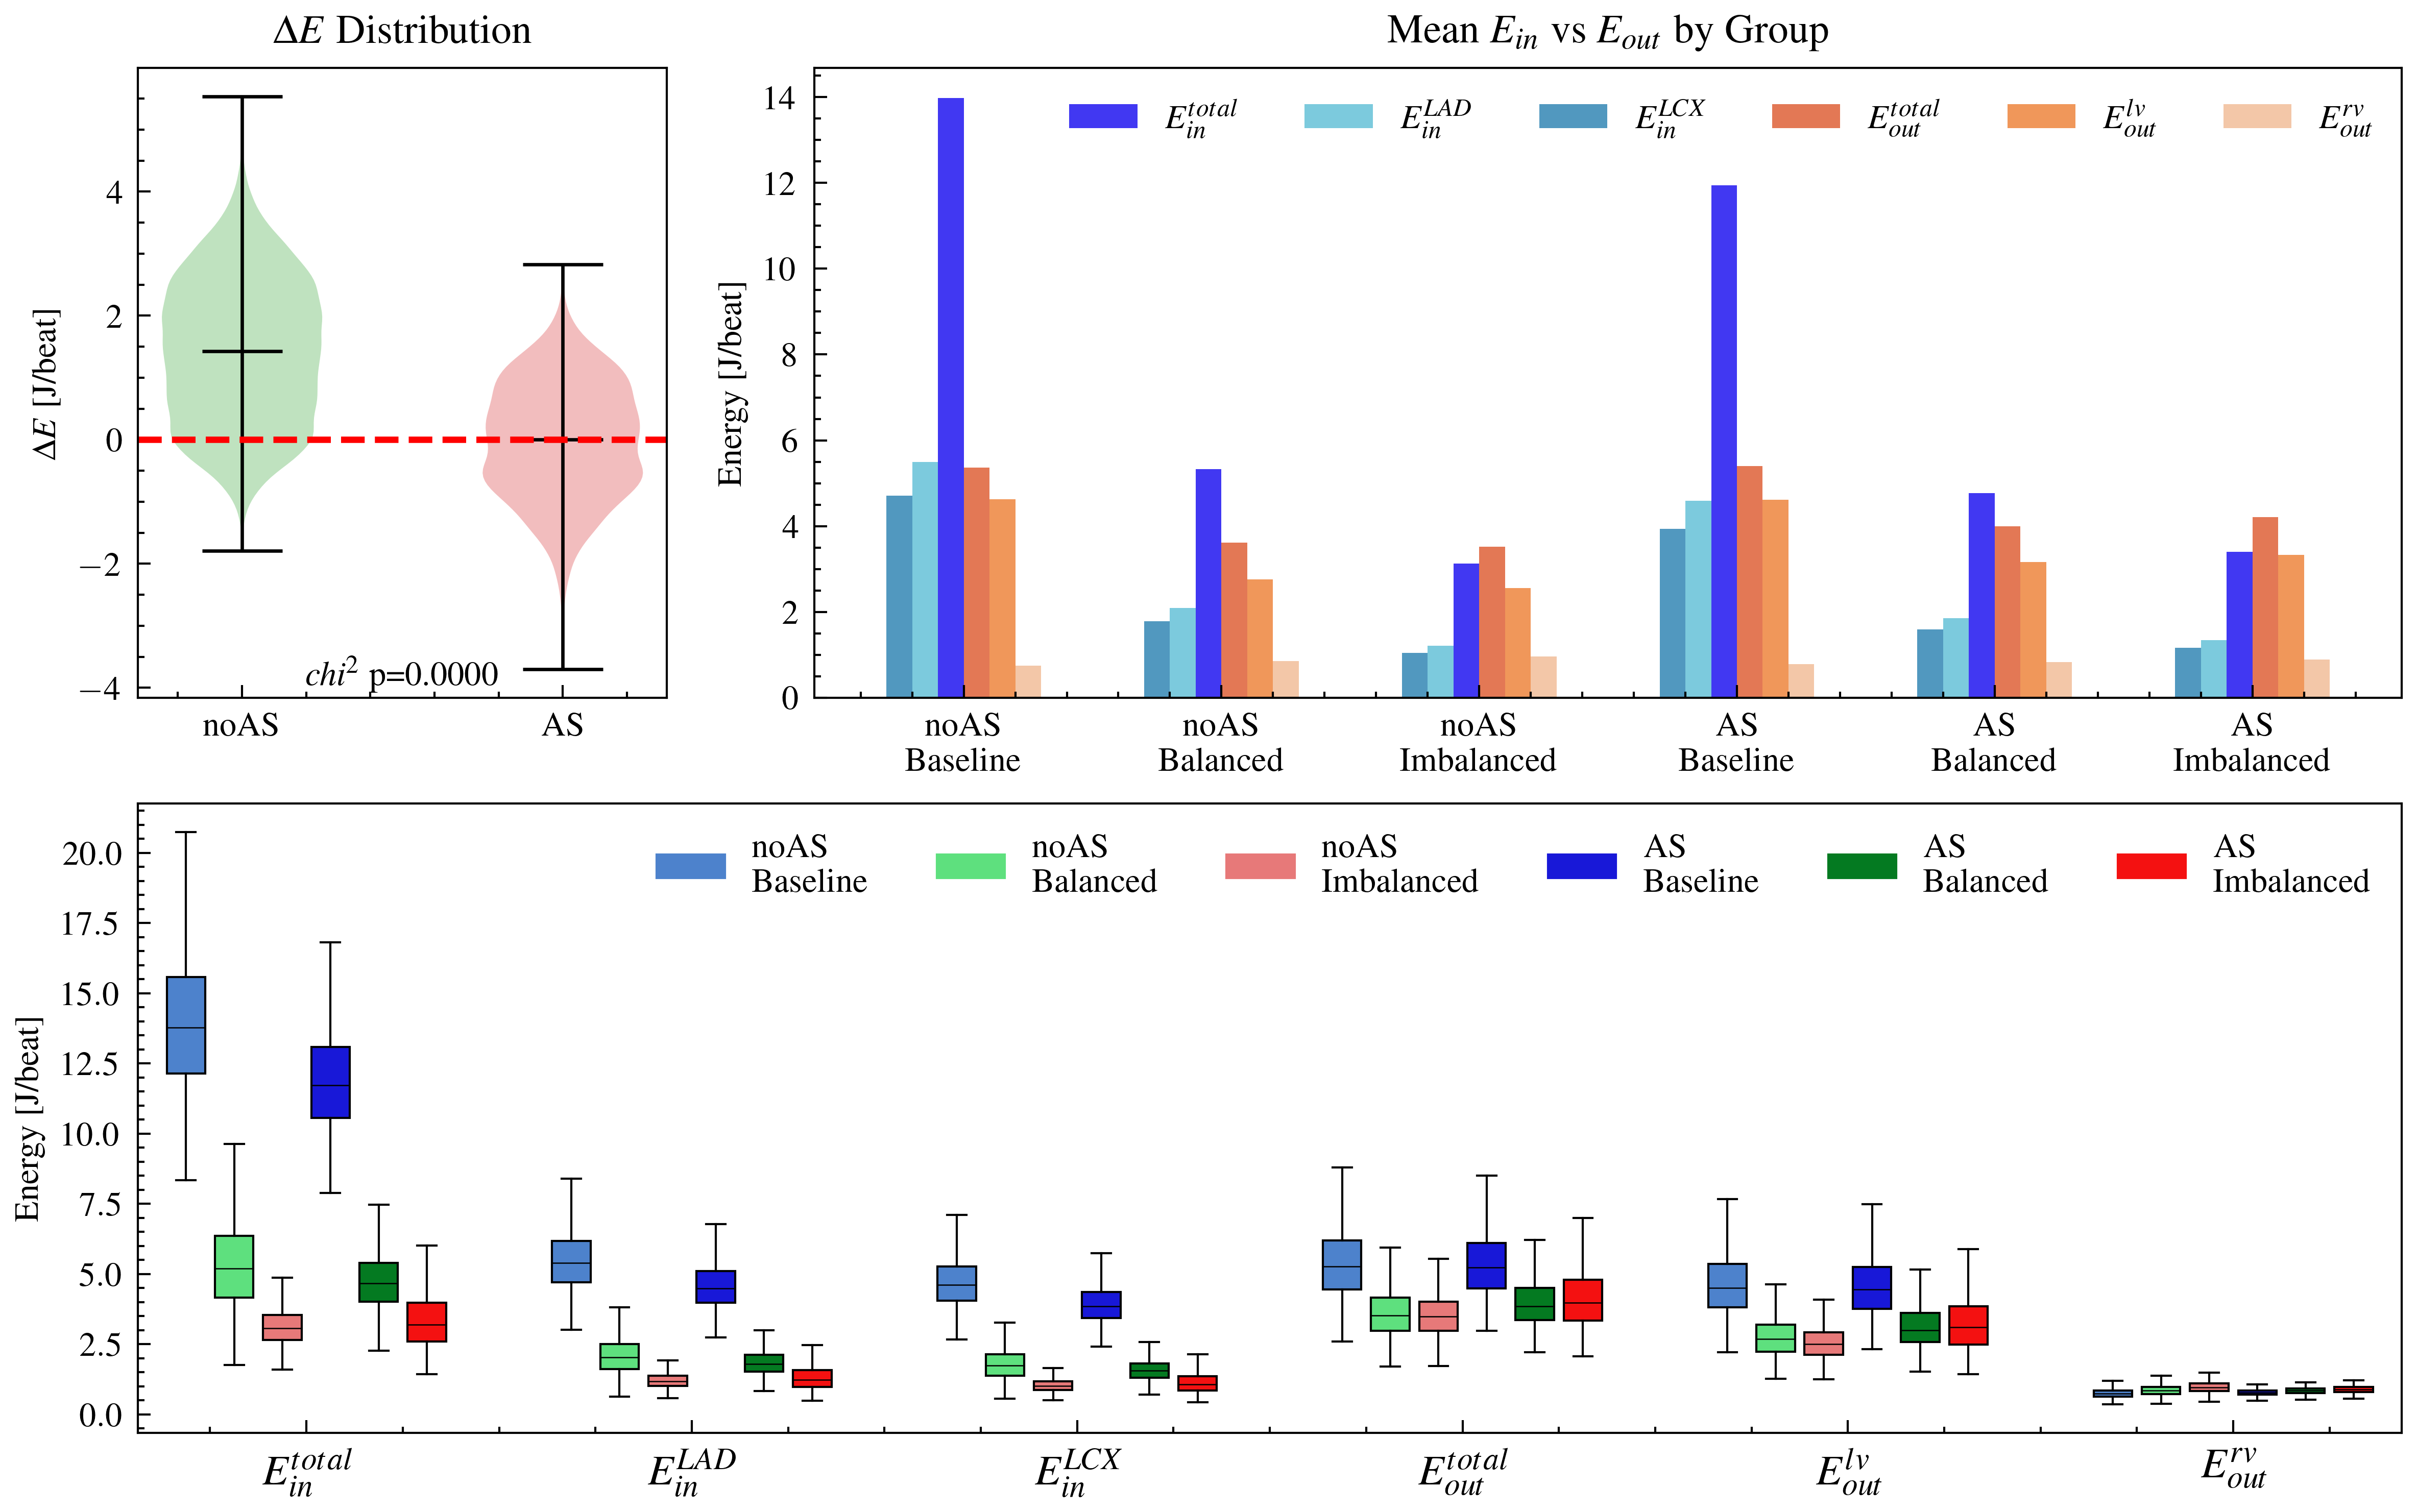

In [ ]:
# simulation 1

output_noAS = output_sim1_noAS
output_AS = output_sim1_AS

COLOR_BALANCED = "#2ca02c"
COLOR_IMBALANCE = "#d62728"
CENTIMETERS = 1/2.54


fig = plt.figure(figsize=(20*CENTIMETERS,12.5*CENTIMETERS), layout="constrained")


gs = fig.add_gridspec(2, 2, width_ratios=[1, 3], height_ratios=[1, 1])


ax = fig.add_subplot(gs[0, 0])
#fig.suptitle(f"noAS vs AS Comparison — Simulation 1", fontweight="bold")

n_noas = len(output_noAS)
n_as   = len(output_AS)

k_noas = len(output_noAS[output_noAS["DeltaE"] < 0])
k_as   = len(output_AS[output_AS["DeltaE"] < 0])

ct = [[k_noas,     n_noas - k_noas],
    [k_as,       n_as   - k_as  ]]

chi2, p_value_chi2, dof, expected = chi2_contingency(ct, correction=False)
fisher, p_value_f = fisher_exact(table=ct, alternative="two-sided") # or less

print("="*60)
print(f"Simulation 1")
print(f"noAS = {100*k_noas/n_noas:.2f}%")
print(f"AS = {100*k_as/n_as:.2f}%")
print(f"chi2={chi2:.3f}, dof={dof}, p={p_value_chi2:.3e}")
print(f"Expected counts:\n{expected}")
print(f"fisher: p={p_value_f:.3e}")

data_plot = [output_noAS["DeltaE"].values, output_AS["DeltaE"].values]
vp = ax.violinplot(data_plot, positions=[1, 2], showmedians=True)
vp["bodies"][0].set_facecolor(COLOR_BALANCED)
vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
for part in ["cbars","cmins","cmaxes","cmedians"]:
    vp[part].set_color("black")
ax.axhline(0, color="red", ls="--", lw=1.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(["noAS", "AS"])
ax.set_ylabel(r"$\Delta E$ [J/beat]")
ax.set_title(r"$\Delta E$ Distribution")
ax.text(0.5, 0.02, r"$chi^2$" + f" p={p_value_chi2:.4f}", transform=ax.transAxes,
    ha="center", fontsize=8)


# Top Right (Row index 0, Column index 1)
ax = fig.add_subplot(gs[0, 1])
groups = ["noAS\nBaseline", "noAS\nBalanced", "noAS\nImbalanced",
        "AS\nBaseline", "AS\nBalanced",   "AS\nImbalanced"]
ein_means = [
    output_selpopulation_noAS["Ein"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein"].mean(),
    output_selpopulation_AS["Ein"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein"].mean(),
]
ein_LAD_means = [
    output_selpopulation_noAS["Ein_LAD"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LAD"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LAD"].mean(),
    output_selpopulation_AS["Ein_LAD"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein_LAD"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein_LAD"].mean(),
]

ein_LCX_means = [
    output_selpopulation_noAS["Ein_LCX"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LCX"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LCX"].mean(),
    output_selpopulation_AS["Ein_LCX"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein_LCX"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein_LCX"].mean(),
]


eout_means = [
    output_selpopulation_noAS["VO2_total"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_total"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_total"].mean(),
    output_selpopulation_AS["VO2_total"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_total"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_total"].mean(),
]
eout_lv_means = [
    output_selpopulation_noAS["VO2_lv"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_lv"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_lv"].mean(),
    output_selpopulation_AS["VO2_lv"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_lv"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_lv"].mean(),
]

eout_rv_means = [
    output_selpopulation_noAS["VO2_rv"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_rv"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_rv"].mean(),
    output_selpopulation_AS["VO2_rv"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_rv"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_rv"].mean(),
]

x = np.arange(6)
w = 0.1
ax.bar(x - 1*w/2, ein_means,  w, label=r"$E_{in}^{total}$",  color="#1206EF", alpha=0.8)
ax.bar(x - 3*w/2, ein_LAD_means,  w, label=r"$E_{in}^{LAD}$",  color="#5BBDD5", alpha=0.8)
ax.bar(x - 5*w/2, ein_LCX_means,  w, label=r"$E_{in}^{LCX}$",  color="#257FAF", alpha=0.8)
ax.bar(x + w/2, eout_means, w, label=r"$E_{out}^{total}$", color="#DC562A", alpha=0.8)
ax.bar(x + 3*w/2, eout_lv_means, w, label=r"$E_{out}^{lv}$", color="#ED7D31", alpha=0.8)
ax.bar(x + 5*w/2, eout_rv_means, w, label=r"$E_{out}^{rv}$", color="#F1B993", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=8)
ax.set_ylabel("Energy [J/beat]")
ax.set_title(r"Mean $E_{in}$ vs $E_{out}$ by Group")
ax.legend(fontsize=8, ncol=6)


# --- BOTTOM ROW ---
ax = fig.add_subplot(gs[1, :]) 
groups = ["noAS\nBaseline", "noAS\nBalanced", "noAS\nImbalanced",
        "AS\nBaseline", "AS\nBalanced",   "AS\nImbalanced"]

ein_list = [
    output_selpopulation_noAS["Ein"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein"],
    output_selpopulation_AS["Ein"],
    output_AS[output_AS["DeltaE"]>=0]["Ein"],
    output_AS[output_AS["DeltaE"]< 0]["Ein"],
]
ein_LAD_list = [
    output_selpopulation_noAS["Ein_LAD"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LAD"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LAD"],
    output_selpopulation_AS["Ein_LAD"],
    output_AS[output_AS["DeltaE"]>=0]["Ein_LAD"],
    output_AS[output_AS["DeltaE"]< 0]["Ein_LAD"],
]

ein_LCX_list = [
    output_selpopulation_noAS["Ein_LCX"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LCX"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LCX"],
    output_selpopulation_AS["Ein_LCX"],
    output_AS[output_AS["DeltaE"]>=0]["Ein_LCX"],
    output_AS[output_AS["DeltaE"]< 0]["Ein_LCX"],
]


eout_list = [
    output_selpopulation_noAS["VO2_total"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_total"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_total"],
    output_selpopulation_AS["VO2_total"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_total"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_total"],
]
eout_lv_list = [
    output_selpopulation_noAS["VO2_lv"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_lv"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_lv"],
    output_selpopulation_AS["VO2_lv"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_lv"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_lv"],
]

eout_rv_list = [
    output_selpopulation_noAS["VO2_rv"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_rv"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_rv"],
    output_selpopulation_AS["VO2_rv"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_rv"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_rv"],
]
data_to_plot = ein_list + ein_LAD_list + ein_LCX_list + eout_list + eout_lv_list + eout_rv_list


positions = []
x_tick_positions = [] 
current_x = 1

for group in range(6):
    group_positions = []
    for box in range(6):
        group_positions.append(current_x)
        current_x += 1 
    
    positions.extend(group_positions)
    
    x_tick_positions.append(np.mean(group_positions))
    
    current_x += 2

bplot = ax.boxplot(data_to_plot, 
                   positions=positions, 
                   widths=0.8,          
                   patch_artist=True,   
                   showfliers=False,
                   boxprops={'linewidth': 0.5, 'color': 'black'},
                   medianprops={'color': 'black', 'linewidth': 0.3},
                   whiskerprops={'linewidth': 0.5},                  
                    capprops={'linewidth': 0.5}                       
                   )
colors = ["#4D82CC", "#5EE07E",  "#E77979", "#1818D8",  "#047A21",  "#F41111"]
ax.set_ylabel("Energy [J/beat]")
for i, box in enumerate(bplot['boxes']):
    box.set_facecolor(colors[i % 6]) 



group_labels = [r"$E_{in}^{total}$", r"$E_{in}^{LAD}$", r"$E_{in}^{LCX}$",
                r"$E_{out}^{total}$", r"$E_{out}^{lv}$", r"$E_{out}^{rv}$"]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(group_labels, fontsize=10)

legend_labels = ['noAS\nBaseline', 'noAS\nBalanced', 'noAS\nImbalanced', 'AS\nBaseline', 'AS\nBalanced', 'AS\nImbalanced']
legend_patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(6)]

ax.legend(handles=legend_patches, fontsize=8, ncol=6)


ax.set_xlim(0, current_x - 2) 

#plt.savefig("obrázky/energies_v2_sim1.svg")
plt.savefig("Figures/energies_sim1.png", dpi=400)
plt.show()

Simulation 1
noAS = 1.93%
AS = 44.04%
chi2=17818.420, dof=1, p=0.000e+00
Expected counts:
[[ 3526.98064536 55070.01935464]
 [  379.01935464  5917.98064536]]
fisher: p=0.000e+00


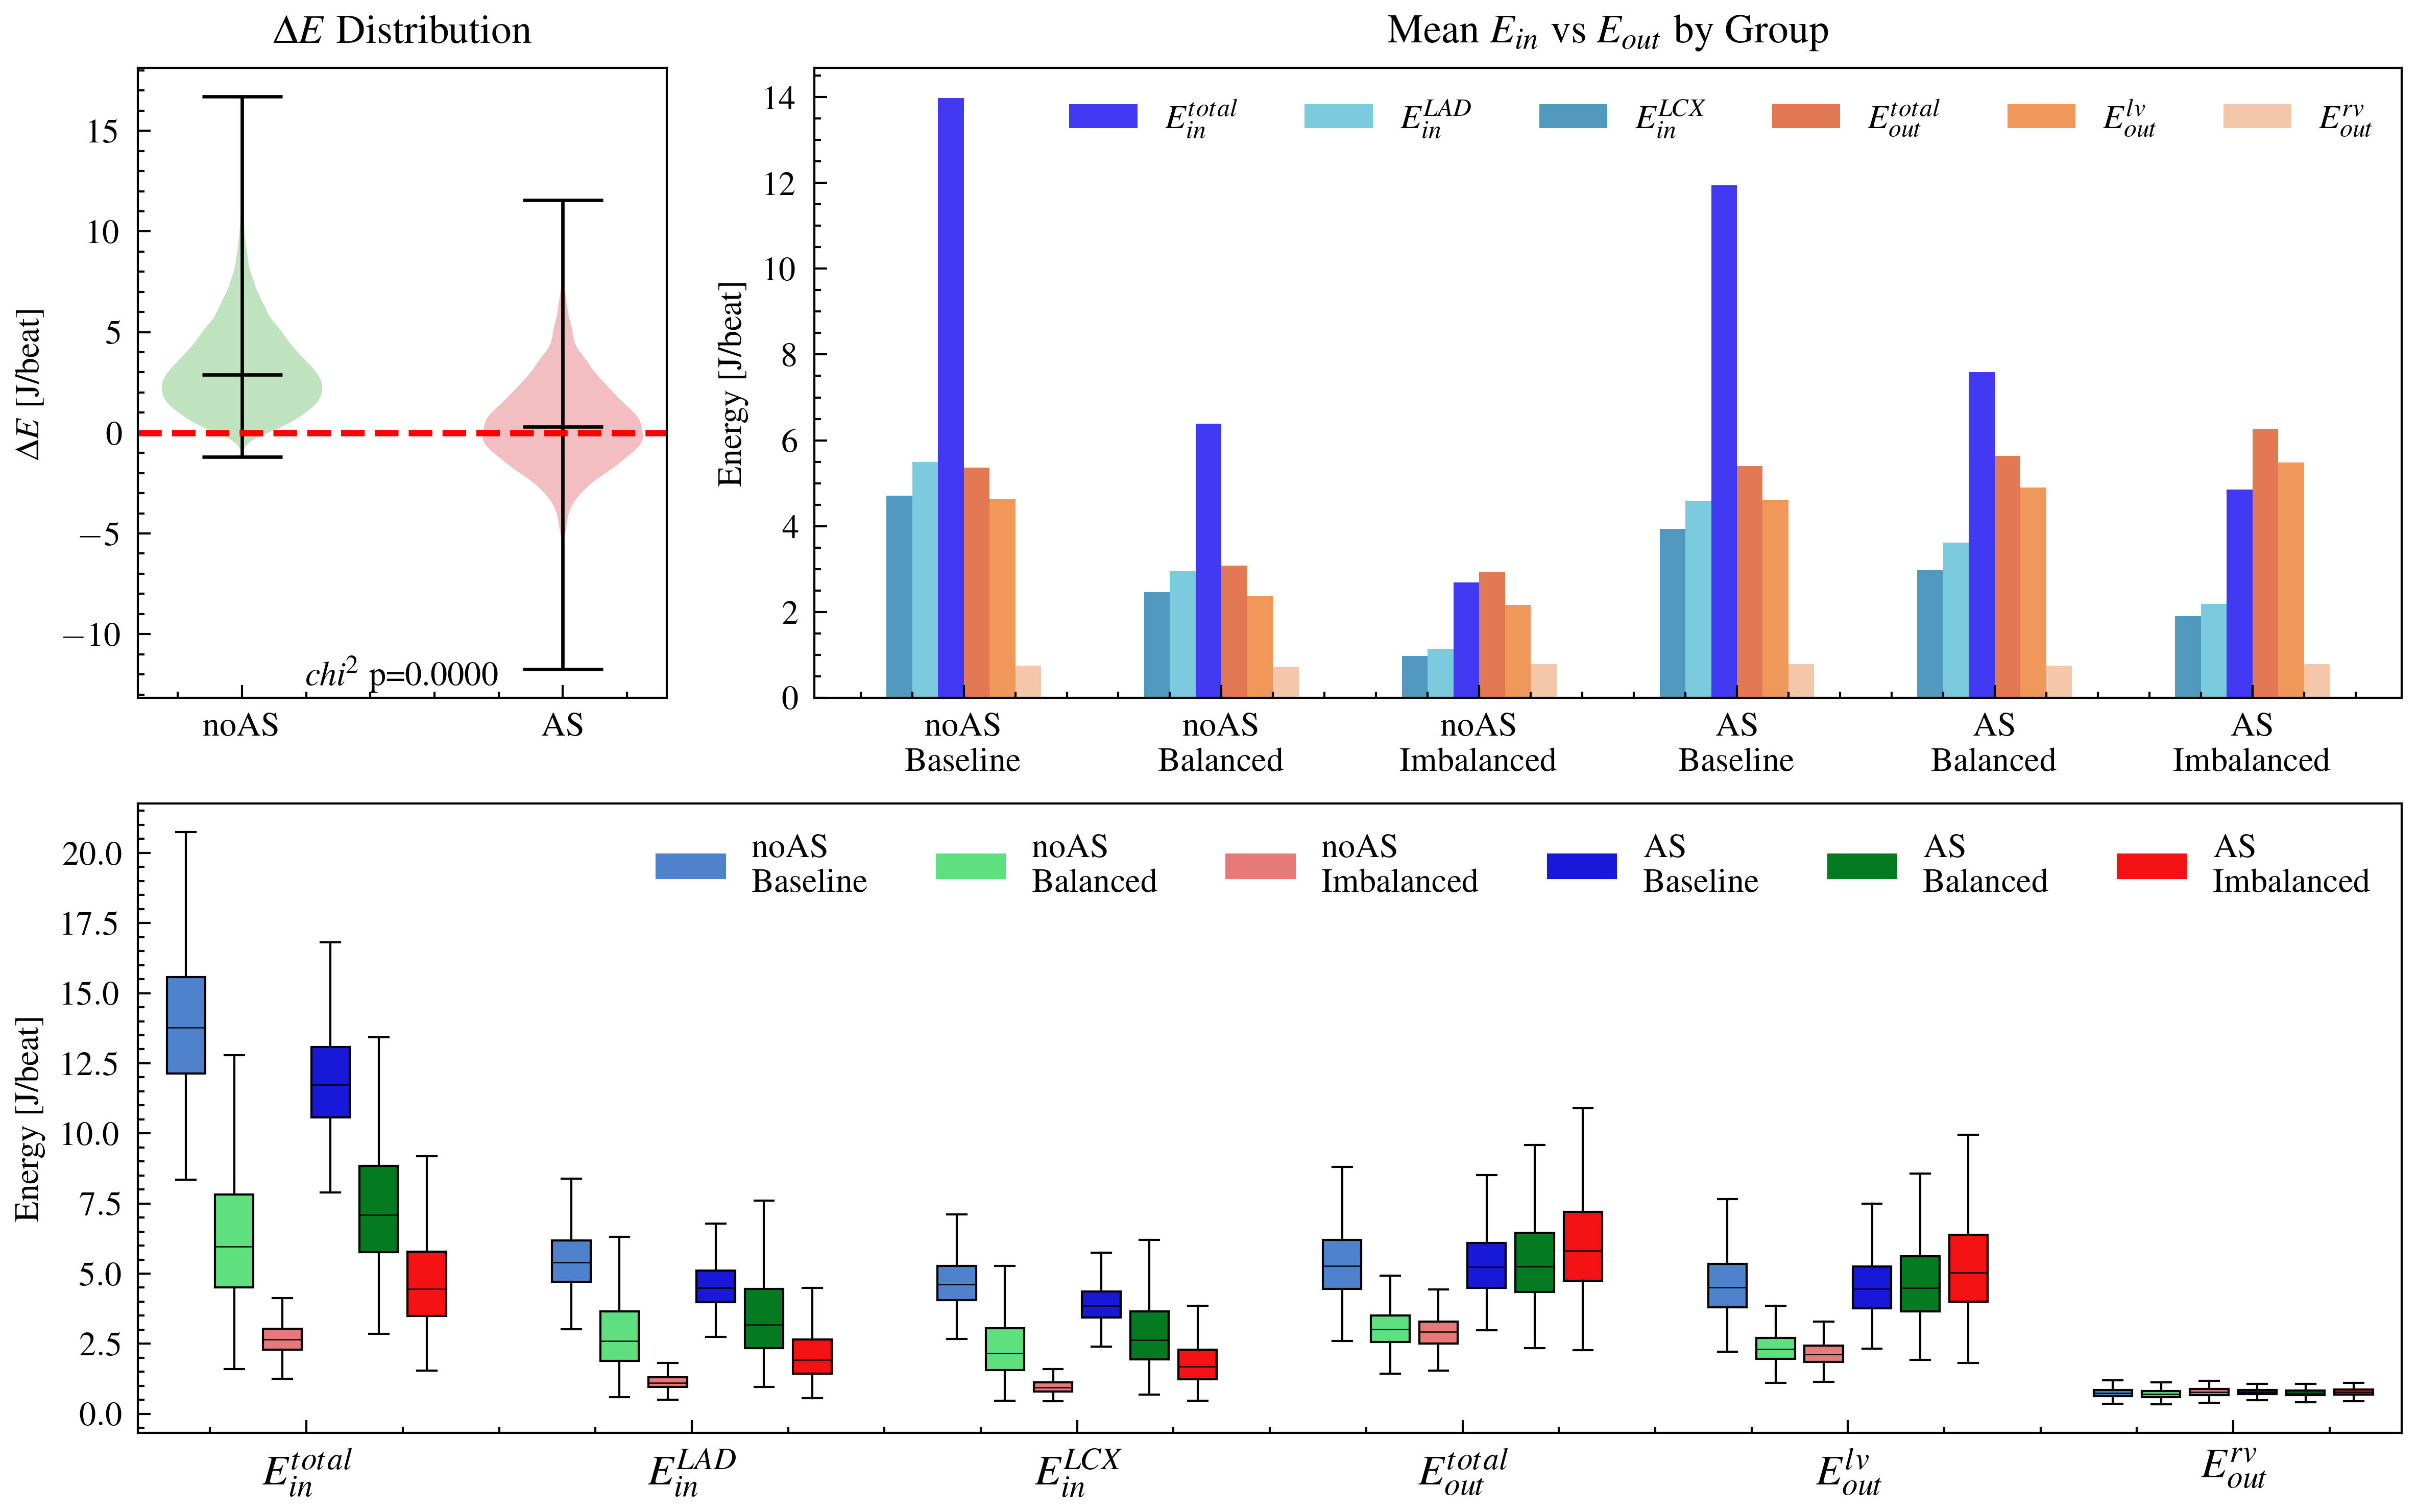

In [ ]:
# simulation 2

output_noAS = output_sim2_noAS
output_AS = output_sim2_AS


fig = plt.figure(figsize=(20*CENTIMETERS,12.5*CENTIMETERS), layout="constrained")


gs = fig.add_gridspec(2, 2, width_ratios=[1, 3], height_ratios=[1, 1])


ax = fig.add_subplot(gs[0, 0])
#fig.suptitle(f"noAS vs AS Comparison — Simulation 1", fontweight="bold")

n_noas = len(output_noAS)
n_as   = len(output_AS)

k_noas = len(output_noAS[output_noAS["DeltaE"] < 0])
k_as   = len(output_AS[output_AS["DeltaE"] < 0])

ct = [[k_noas,     n_noas - k_noas],
    [k_as,       n_as   - k_as  ]]

chi2, p_value_chi2, dof, expected = chi2_contingency(ct, correction=False)
fisher, p_value_f = fisher_exact(table=ct, alternative="two-sided") # or less

print("="*60)
print(f"Simulation 1")
print(f"noAS = {100*k_noas/n_noas:.2f}%")
print(f"AS = {100*k_as/n_as:.2f}%")
print(f"chi2={chi2:.3f}, dof={dof}, p={p_value_chi2:.3e}")
print(f"Expected counts:\n{expected}")
print(f"fisher: p={p_value_f:.3e}")

data_plot = [output_noAS["DeltaE"].values, output_AS["DeltaE"].values]
vp = ax.violinplot(data_plot, positions=[1, 2], showmedians=True)
vp["bodies"][0].set_facecolor(COLOR_BALANCED)
vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
for part in ["cbars","cmins","cmaxes","cmedians"]:
    vp[part].set_color("black")
ax.axhline(0, color="red", ls="--", lw=1.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(["noAS", "AS"])
ax.set_ylabel(r"$\Delta E$ [J/beat]")
ax.set_title(r"$\Delta E$ Distribution")
ax.text(0.5, 0.02, r"$chi^2$" + f" p={p_value_chi2:.4f}", transform=ax.transAxes,
    ha="center", fontsize=8)


ax = fig.add_subplot(gs[0, 1])
groups = ["noAS\nBaseline", "noAS\nBalanced", "noAS\nImbalanced",
        "AS\nBaseline", "AS\nBalanced",   "AS\nImbalanced"]
ein_means = [
    output_selpopulation_noAS["Ein"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein"].mean(),
    output_selpopulation_AS["Ein"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein"].mean(),
]
ein_LAD_means = [
    output_selpopulation_noAS["Ein_LAD"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LAD"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LAD"].mean(),
    output_selpopulation_AS["Ein_LAD"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein_LAD"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein_LAD"].mean(),
]

ein_LCX_means = [
    output_selpopulation_noAS["Ein_LCX"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LCX"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LCX"].mean(),
    output_selpopulation_AS["Ein_LCX"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein_LCX"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein_LCX"].mean(),
]


eout_means = [
    output_selpopulation_noAS["VO2_total"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_total"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_total"].mean(),
    output_selpopulation_AS["VO2_total"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_total"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_total"].mean(),
]
eout_lv_means = [
    output_selpopulation_noAS["VO2_lv"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_lv"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_lv"].mean(),
    output_selpopulation_AS["VO2_lv"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_lv"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_lv"].mean(),
]

eout_rv_means = [
    output_selpopulation_noAS["VO2_rv"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_rv"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_rv"].mean(),
    output_selpopulation_AS["VO2_rv"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_rv"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_rv"].mean(),
]

x = np.arange(6)
w = 0.1
ax.bar(x - 1*w/2, ein_means,  w, label=r"$E_{in}^{total}$",  color="#1206EF", alpha=0.8)
ax.bar(x - 3*w/2, ein_LAD_means,  w, label=r"$E_{in}^{LAD}$",  color="#5BBDD5", alpha=0.8)
ax.bar(x - 5*w/2, ein_LCX_means,  w, label=r"$E_{in}^{LCX}$",  color="#257FAF", alpha=0.8)
ax.bar(x + w/2, eout_means, w, label=r"$E_{out}^{total}$", color="#DC562A", alpha=0.8)
ax.bar(x + 3*w/2, eout_lv_means, w, label=r"$E_{out}^{lv}$", color="#ED7D31", alpha=0.8)
ax.bar(x + 5*w/2, eout_rv_means, w, label=r"$E_{out}^{rv}$", color="#F1B993", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=8)
ax.set_ylabel("Energy [J/beat]")
ax.set_title(r"Mean $E_{in}$ vs $E_{out}$ by Group")
ax.legend(fontsize=8, ncol=6)


# --- BOTTOM ROW ---

ax = fig.add_subplot(gs[1, :]) 
groups = ["noAS\nBaseline", "noAS\nBalanced", "noAS\nImbalanced",
        "AS\nBaseline", "AS\nBalanced",   "AS\nImbalanced"]

ein_list = [
    output_selpopulation_noAS["Ein"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein"],
    output_selpopulation_AS["Ein"],
    output_AS[output_AS["DeltaE"]>=0]["Ein"],
    output_AS[output_AS["DeltaE"]< 0]["Ein"],
]
ein_LAD_list = [
    output_selpopulation_noAS["Ein_LAD"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LAD"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LAD"],
    output_selpopulation_AS["Ein_LAD"],
    output_AS[output_AS["DeltaE"]>=0]["Ein_LAD"],
    output_AS[output_AS["DeltaE"]< 0]["Ein_LAD"],
]

ein_LCX_list = [
    output_selpopulation_noAS["Ein_LCX"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LCX"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LCX"],
    output_selpopulation_AS["Ein_LCX"],
    output_AS[output_AS["DeltaE"]>=0]["Ein_LCX"],
    output_AS[output_AS["DeltaE"]< 0]["Ein_LCX"],
]


eout_list = [
    output_selpopulation_noAS["VO2_total"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_total"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_total"],
    output_selpopulation_AS["VO2_total"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_total"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_total"],
]
eout_lv_list = [
    output_selpopulation_noAS["VO2_lv"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_lv"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_lv"],
    output_selpopulation_AS["VO2_lv"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_lv"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_lv"],
]

eout_rv_list = [
    output_selpopulation_noAS["VO2_rv"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_rv"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_rv"],
    output_selpopulation_AS["VO2_rv"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_rv"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_rv"],
]
data_to_plot = ein_list + ein_LAD_list + ein_LCX_list + eout_list + eout_lv_list + eout_rv_list


positions = []
x_tick_positions = [] 
current_x = 1

for group in range(6):
    group_positions = []
    for box in range(6):
        group_positions.append(current_x)
        current_x += 1 
    
    positions.extend(group_positions)
    
    
    x_tick_positions.append(np.mean(group_positions))
    
    
    current_x += 2

bplot = ax.boxplot(data_to_plot, 
                   positions=positions, 
                   widths=0.8,          
                   patch_artist=True,   
                   showfliers=False,
                   boxprops={'linewidth': 0.5, 'color': 'black'},
                   medianprops={'color': 'black', 'linewidth': 0.3},
                   whiskerprops={'linewidth': 0.5},                  
                    capprops={'linewidth': 0.5}                       
                   )
colors = ["#4D82CC", "#5EE07E",  "#E77979", "#1818D8",  "#047A21",  "#F41111"]
ax.set_ylabel("Energy [J/beat]")
for i, box in enumerate(bplot['boxes']):
    box.set_facecolor(colors[i % 6]) 



group_labels = [r"$E_{in}^{total}$", r"$E_{in}^{LAD}$", r"$E_{in}^{LCX}$",
                r"$E_{out}^{total}$", r"$E_{out}^{lv}$", r"$E_{out}^{rv}$"]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(group_labels, fontsize=10)

legend_labels = ['noAS\nBaseline', 'noAS\nBalanced', 'noAS\nImbalanced', 'AS\nBaseline', 'AS\nBalanced', 'AS\nImbalanced']
legend_patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(6)]

ax.legend(handles=legend_patches, fontsize=8, ncol=6)

ax.set_xlim(0, current_x - 2) # Cut off extra empty space at the end

plt.savefig("Figures/energies_sim2.png", dpi=400)
plt.show()

Simulation 1
noAS = 0.65%
AS = 5.10%
chi2=1053.333, dof=1, p=4.591e-231
Expected counts:
[[  632.97834931 57964.02165069]
 [   68.02165069  6228.97834931]]
fisher: p=8.857e-137


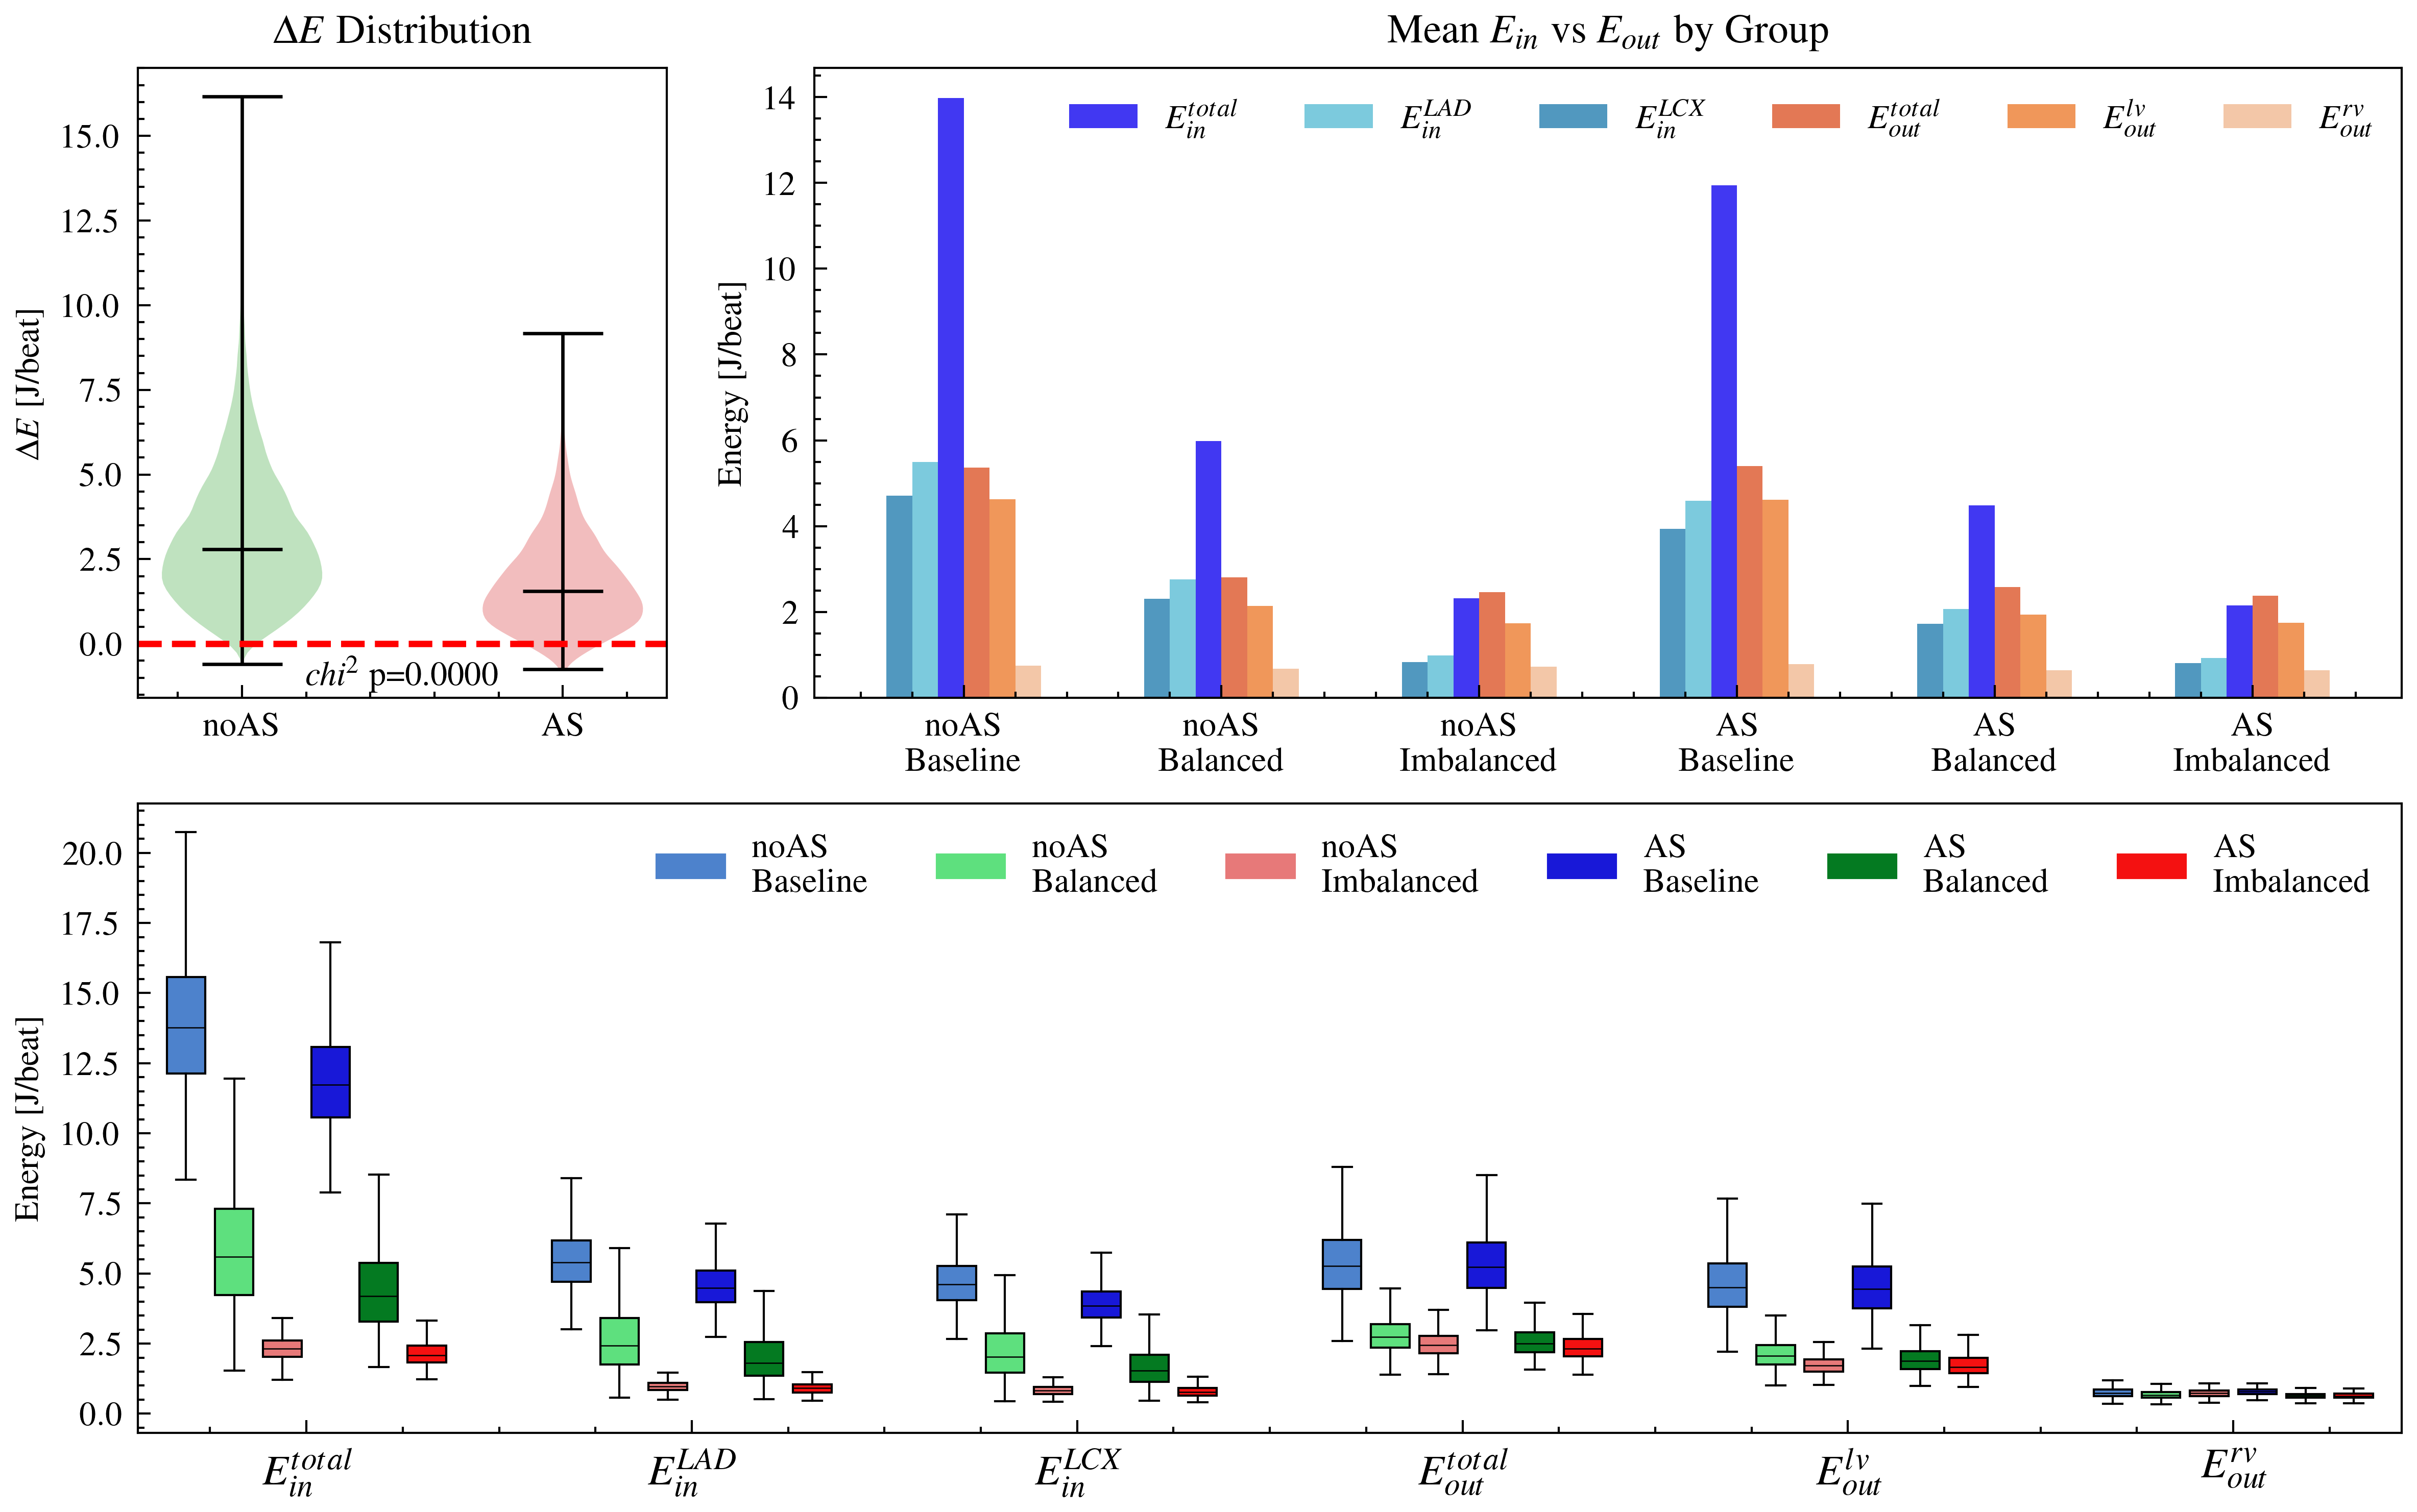

In [ ]:
# simulation 3

output_noAS = output_sim3_noAS
output_AS = output_sim3_AS


fig = plt.figure(figsize=(20*CENTIMETERS,12.5*CENTIMETERS), layout="constrained")

gs = fig.add_gridspec(2, 2, width_ratios=[1, 3], height_ratios=[1, 1])


ax = fig.add_subplot(gs[0, 0])
#fig.suptitle(f"noAS vs AS Comparison — Simulation 1", fontweight="bold")

n_noas = len(output_noAS)
n_as   = len(output_AS)

k_noas = len(output_noAS[output_noAS["DeltaE"] < 0])
k_as   = len(output_AS[output_AS["DeltaE"] < 0])

ct = [[k_noas,     n_noas - k_noas],
    [k_as,       n_as   - k_as  ]]

chi2, p_value_chi2, dof, expected = chi2_contingency(ct, correction=False)
fisher, p_value_f = fisher_exact(table=ct, alternative="two-sided") # or less

print("="*60)
print(f"Simulation 1")
print(f"noAS = {100*k_noas/n_noas:.2f}%")
print(f"AS = {100*k_as/n_as:.2f}%")
print(f"chi2={chi2:.3f}, dof={dof}, p={p_value_chi2:.3e}")
print(f"Expected counts:\n{expected}")
print(f"fisher: p={p_value_f:.3e}")

data_plot = [output_noAS["DeltaE"].values, output_AS["DeltaE"].values]
vp = ax.violinplot(data_plot, positions=[1, 2], showmedians=True)
vp["bodies"][0].set_facecolor(COLOR_BALANCED)
vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
for part in ["cbars","cmins","cmaxes","cmedians"]:
    vp[part].set_color("black")
ax.axhline(0, color="red", ls="--", lw=1.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(["noAS", "AS"])
ax.set_ylabel(r"$\Delta E$ [J/beat]")
ax.set_title(r"$\Delta E$ Distribution")
ax.text(0.5, 0.02, r"$chi^2$" + f" p={p_value_chi2:.4f}", transform=ax.transAxes,
    ha="center", fontsize=8)


ax = fig.add_subplot(gs[0, 1])
groups = ["noAS\nBaseline", "noAS\nBalanced", "noAS\nImbalanced",
        "AS\nBaseline", "AS\nBalanced",   "AS\nImbalanced"]
ein_means = [
    output_selpopulation_noAS["Ein"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein"].mean(),
    output_selpopulation_AS["Ein"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein"].mean(),
]
ein_LAD_means = [
    output_selpopulation_noAS["Ein_LAD"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LAD"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LAD"].mean(),
    output_selpopulation_AS["Ein_LAD"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein_LAD"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein_LAD"].mean(),
]

ein_LCX_means = [
    output_selpopulation_noAS["Ein_LCX"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LCX"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LCX"].mean(),
    output_selpopulation_AS["Ein_LCX"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein_LCX"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein_LCX"].mean(),
]


eout_means = [
    output_selpopulation_noAS["VO2_total"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_total"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_total"].mean(),
    output_selpopulation_AS["VO2_total"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_total"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_total"].mean(),
]
eout_lv_means = [
    output_selpopulation_noAS["VO2_lv"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_lv"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_lv"].mean(),
    output_selpopulation_AS["VO2_lv"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_lv"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_lv"].mean(),
]

eout_rv_means = [
    output_selpopulation_noAS["VO2_rv"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_rv"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_rv"].mean(),
    output_selpopulation_AS["VO2_rv"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_rv"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_rv"].mean(),
]

x = np.arange(6)
w = 0.1
ax.bar(x - 1*w/2, ein_means,  w, label=r"$E_{in}^{total}$",  color="#1206EF", alpha=0.8)
ax.bar(x - 3*w/2, ein_LAD_means,  w, label=r"$E_{in}^{LAD}$",  color="#5BBDD5", alpha=0.8)
ax.bar(x - 5*w/2, ein_LCX_means,  w, label=r"$E_{in}^{LCX}$",  color="#257FAF", alpha=0.8)
ax.bar(x + w/2, eout_means, w, label=r"$E_{out}^{total}$", color="#DC562A", alpha=0.8)
ax.bar(x + 3*w/2, eout_lv_means, w, label=r"$E_{out}^{lv}$", color="#ED7D31", alpha=0.8)
ax.bar(x + 5*w/2, eout_rv_means, w, label=r"$E_{out}^{rv}$", color="#F1B993", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=8)
ax.set_ylabel("Energy [J/beat]")
ax.set_title(r"Mean $E_{in}$ vs $E_{out}$ by Group")
ax.legend(fontsize=8, ncol=6)


# --- BOTTOM ROW ---

ax = fig.add_subplot(gs[1, :]) 
groups = ["noAS\nBaseline", "noAS\nBalanced", "noAS\nImbalanced",
        "AS\nBaseline", "AS\nBalanced",   "AS\nImbalanced"]

ein_list = [
    output_selpopulation_noAS["Ein"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein"],
    output_selpopulation_AS["Ein"],
    output_AS[output_AS["DeltaE"]>=0]["Ein"],
    output_AS[output_AS["DeltaE"]< 0]["Ein"],
]
ein_LAD_list = [
    output_selpopulation_noAS["Ein_LAD"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LAD"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LAD"],
    output_selpopulation_AS["Ein_LAD"],
    output_AS[output_AS["DeltaE"]>=0]["Ein_LAD"],
    output_AS[output_AS["DeltaE"]< 0]["Ein_LAD"],
]

ein_LCX_list = [
    output_selpopulation_noAS["Ein_LCX"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LCX"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LCX"],
    output_selpopulation_AS["Ein_LCX"],
    output_AS[output_AS["DeltaE"]>=0]["Ein_LCX"],
    output_AS[output_AS["DeltaE"]< 0]["Ein_LCX"],
]


eout_list = [
    output_selpopulation_noAS["VO2_total"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_total"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_total"],
    output_selpopulation_AS["VO2_total"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_total"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_total"],
]
eout_lv_list = [
    output_selpopulation_noAS["VO2_lv"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_lv"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_lv"],
    output_selpopulation_AS["VO2_lv"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_lv"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_lv"],
]

eout_rv_list = [
    output_selpopulation_noAS["VO2_rv"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_rv"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_rv"],
    output_selpopulation_AS["VO2_rv"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_rv"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_rv"],
]
data_to_plot = ein_list + ein_LAD_list + ein_LCX_list + eout_list + eout_lv_list + eout_rv_list


positions = []
x_tick_positions = [] 
current_x = 1

for group in range(6):
    group_positions = []
    for box in range(6):
        group_positions.append(current_x)
        current_x += 1 
    
    positions.extend(group_positions)
    
    x_tick_positions.append(np.mean(group_positions))
    
    current_x += 2

bplot = ax.boxplot(data_to_plot, 
                   positions=positions, 
                   widths=0.8,          
                   patch_artist=True,  
                   showfliers=False,
                   boxprops={'linewidth': 0.5, 'color': 'black'},
                   medianprops={'color': 'black', 'linewidth': 0.3},
                   whiskerprops={'linewidth': 0.5},                  
                    capprops={'linewidth': 0.5}                       
                   )
colors = ["#4D82CC", "#5EE07E",  "#E77979", "#1818D8",  "#047A21",  "#F41111"]
ax.set_ylabel("Energy [J/beat]")
for i, box in enumerate(bplot['boxes']):
    box.set_facecolor(colors[i % 6]) 



group_labels = [r"$E_{in}^{total}$", r"$E_{in}^{LAD}$", r"$E_{in}^{LCX}$",
                r"$E_{out}^{total}$", r"$E_{out}^{lv}$", r"$E_{out}^{rv}$"]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(group_labels, fontsize=10)

legend_labels = ['noAS\nBaseline', 'noAS\nBalanced', 'noAS\nImbalanced', 'AS\nBaseline', 'AS\nBalanced', 'AS\nImbalanced']
legend_patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(6)]

ax.legend(handles=legend_patches, fontsize=8, ncol=6)


ax.set_xlim(0, current_x - 2) 

plt.savefig("Figures/energies_sim3.png", dpi=400)
plt.show()

Simulation 1
noAS = 0.00%
AS = 0.11%
chi2=55.267, dof=1, p=1.052e-13
Expected counts:
[[7.22371868e+00 5.85897763e+04]
 [7.76281320e-01 6.29622372e+03]]
fisher: p=5.913e-07


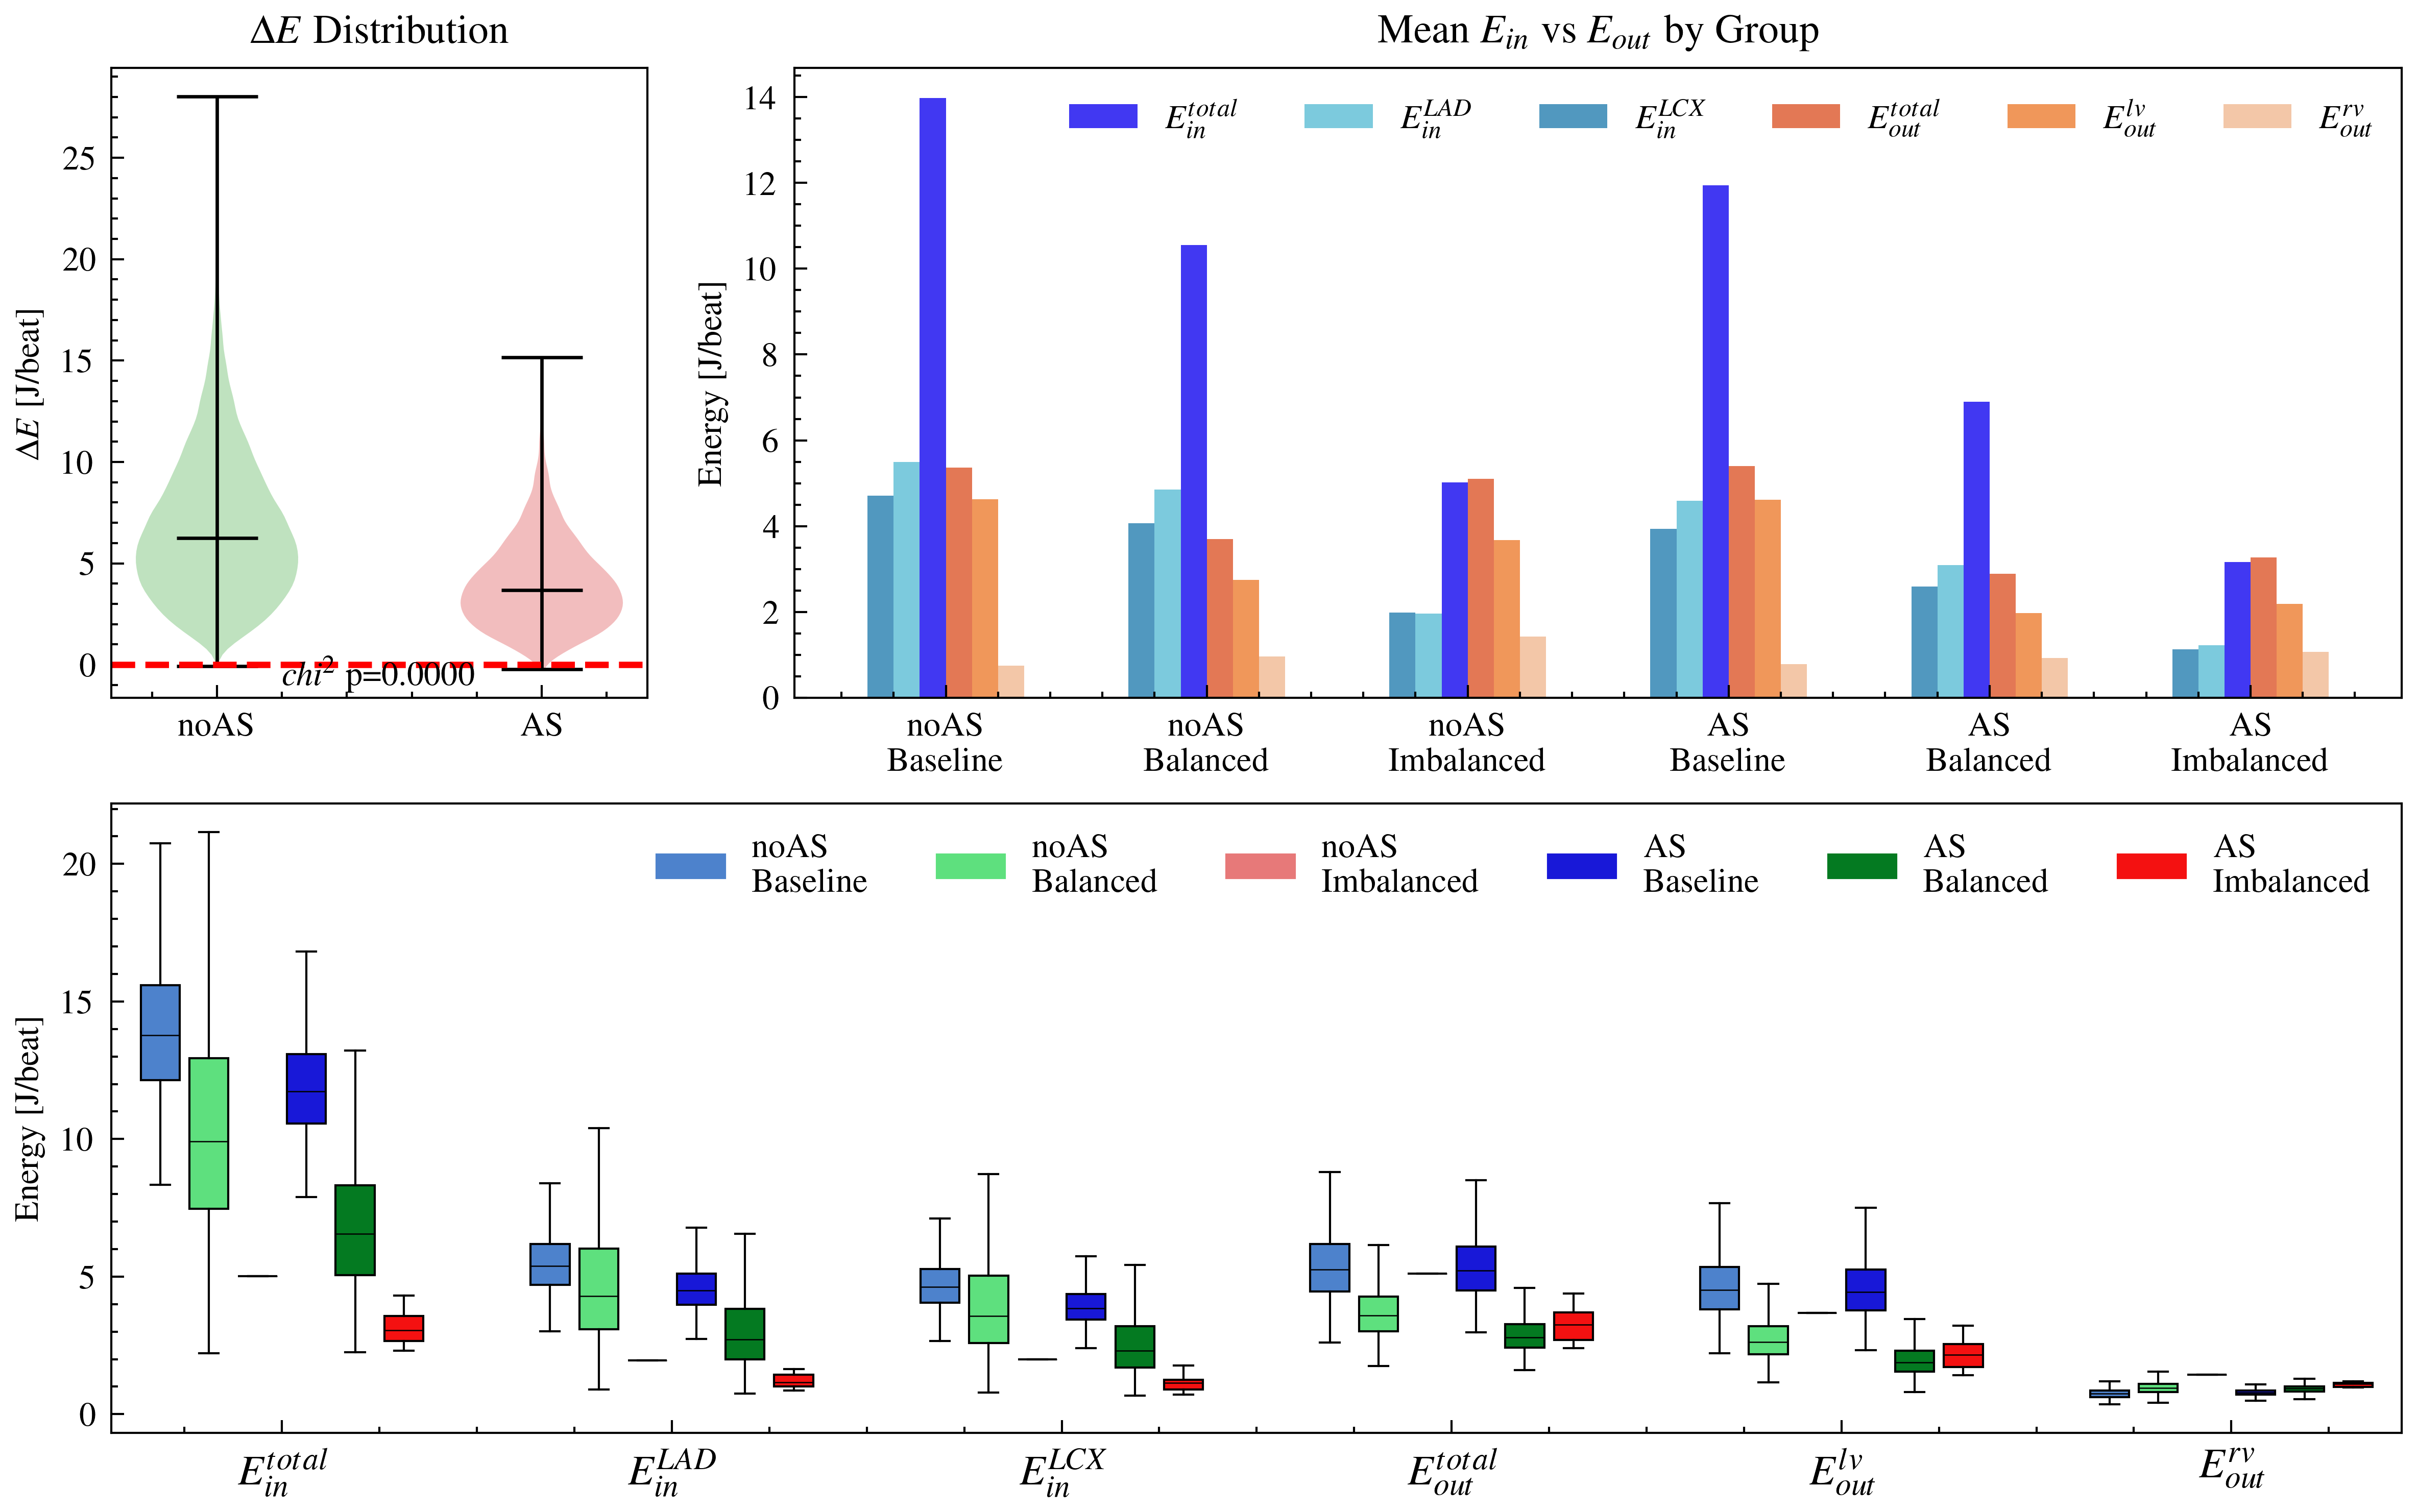

In [ ]:
# simulation 4

output_noAS = output_sim4_noAS
output_AS = output_sim4_AS


fig = plt.figure(figsize=(20*CENTIMETERS,12.5*CENTIMETERS), layout="constrained")


gs = fig.add_gridspec(2, 2, width_ratios=[1, 3], height_ratios=[1, 1])

ax = fig.add_subplot(gs[0, 0])
#fig.suptitle(f"noAS vs AS Comparison — Simulation 1", fontweight="bold")

n_noas = len(output_noAS)
n_as   = len(output_AS)

k_noas = len(output_noAS[output_noAS["DeltaE"] < 0])
k_as   = len(output_AS[output_AS["DeltaE"] < 0])

ct = [[k_noas,     n_noas - k_noas],
    [k_as,       n_as   - k_as  ]]

chi2, p_value_chi2, dof, expected = chi2_contingency(ct, correction=False)
fisher, p_value_f = fisher_exact(table=ct, alternative="two-sided") # or less

print("="*60)
print(f"Simulation 1")
print(f"noAS = {100*k_noas/n_noas:.2f}%")
print(f"AS = {100*k_as/n_as:.2f}%")
print(f"chi2={chi2:.3f}, dof={dof}, p={p_value_chi2:.3e}")
print(f"Expected counts:\n{expected}")
print(f"fisher: p={p_value_f:.3e}")

data_plot = [output_noAS["DeltaE"].values, output_AS["DeltaE"].values]
vp = ax.violinplot(data_plot, positions=[1, 2], showmedians=True)
vp["bodies"][0].set_facecolor(COLOR_BALANCED)
vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
for part in ["cbars","cmins","cmaxes","cmedians"]:
    vp[part].set_color("black")
ax.axhline(0, color="red", ls="--", lw=1.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(["noAS", "AS"])
ax.set_ylabel(r"$\Delta E$ [J/beat]")
ax.set_title(r"$\Delta E$ Distribution")
ax.text(0.5, 0.02, r"$chi^2$" + f" p={p_value_chi2:.4f}", transform=ax.transAxes,
    ha="center", fontsize=8)


ax = fig.add_subplot(gs[0, 1])
groups = ["noAS\nBaseline", "noAS\nBalanced", "noAS\nImbalanced",
        "AS\nBaseline", "AS\nBalanced",   "AS\nImbalanced"]
ein_means = [
    output_selpopulation_noAS["Ein"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein"].mean(),
    output_selpopulation_AS["Ein"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein"].mean(),
]
ein_LAD_means = [
    output_selpopulation_noAS["Ein_LAD"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LAD"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LAD"].mean(),
    output_selpopulation_AS["Ein_LAD"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein_LAD"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein_LAD"].mean(),
]

ein_LCX_means = [
    output_selpopulation_noAS["Ein_LCX"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LCX"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LCX"].mean(),
    output_selpopulation_AS["Ein_LCX"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["Ein_LCX"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["Ein_LCX"].mean(),
]


eout_means = [
    output_selpopulation_noAS["VO2_total"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_total"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_total"].mean(),
    output_selpopulation_AS["VO2_total"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_total"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_total"].mean(),
]
eout_lv_means = [
    output_selpopulation_noAS["VO2_lv"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_lv"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_lv"].mean(),
    output_selpopulation_AS["VO2_lv"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_lv"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_lv"].mean(),
]

eout_rv_means = [
    output_selpopulation_noAS["VO2_rv"].mean(),
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_rv"].mean(),
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_rv"].mean(),
    output_selpopulation_AS["VO2_rv"].mean(),
    output_AS[output_AS["DeltaE"]>=0]["VO2_rv"].mean(),
    output_AS[output_AS["DeltaE"]< 0]["VO2_rv"].mean(),
]

x = np.arange(6)
w = 0.1
ax.bar(x - 1*w/2, ein_means,  w, label=r"$E_{in}^{total}$",  color="#1206EF", alpha=0.8)
ax.bar(x - 3*w/2, ein_LAD_means,  w, label=r"$E_{in}^{LAD}$",  color="#5BBDD5", alpha=0.8)
ax.bar(x - 5*w/2, ein_LCX_means,  w, label=r"$E_{in}^{LCX}$",  color="#257FAF", alpha=0.8)
ax.bar(x + w/2, eout_means, w, label=r"$E_{out}^{total}$", color="#DC562A", alpha=0.8)
ax.bar(x + 3*w/2, eout_lv_means, w, label=r"$E_{out}^{lv}$", color="#ED7D31", alpha=0.8)
ax.bar(x + 5*w/2, eout_rv_means, w, label=r"$E_{out}^{rv}$", color="#F1B993", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=8)
ax.set_ylabel("Energy [J/beat]")
ax.set_title(r"Mean $E_{in}$ vs $E_{out}$ by Group")
ax.legend(fontsize=8, ncol=6)


# --- BOTTOM ROW ---

ax = fig.add_subplot(gs[1, :]) 
groups = ["noAS\nBaseline", "noAS\nBalanced", "noAS\nImbalanced",
        "AS\nBaseline", "AS\nBalanced",   "AS\nImbalanced"]

ein_list = [
    output_selpopulation_noAS["Ein"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein"],
    output_selpopulation_AS["Ein"],
    output_AS[output_AS["DeltaE"]>=0]["Ein"],
    output_AS[output_AS["DeltaE"]< 0]["Ein"],
]
ein_LAD_list = [
    output_selpopulation_noAS["Ein_LAD"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LAD"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LAD"],
    output_selpopulation_AS["Ein_LAD"],
    output_AS[output_AS["DeltaE"]>=0]["Ein_LAD"],
    output_AS[output_AS["DeltaE"]< 0]["Ein_LAD"],
]

ein_LCX_list = [
    output_selpopulation_noAS["Ein_LCX"],
    output_noAS[output_noAS["DeltaE"]>=0]["Ein_LCX"],
    output_noAS[output_noAS["DeltaE"]< 0]["Ein_LCX"],
    output_selpopulation_AS["Ein_LCX"],
    output_AS[output_AS["DeltaE"]>=0]["Ein_LCX"],
    output_AS[output_AS["DeltaE"]< 0]["Ein_LCX"],
]


eout_list = [
    output_selpopulation_noAS["VO2_total"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_total"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_total"],
    output_selpopulation_AS["VO2_total"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_total"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_total"],
]
eout_lv_list = [
    output_selpopulation_noAS["VO2_lv"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_lv"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_lv"],
    output_selpopulation_AS["VO2_lv"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_lv"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_lv"],
]

eout_rv_list = [
    output_selpopulation_noAS["VO2_rv"],
    output_noAS[output_noAS["DeltaE"]>=0]["VO2_rv"],
    output_noAS[output_noAS["DeltaE"]< 0]["VO2_rv"],
    output_selpopulation_AS["VO2_rv"],
    output_AS[output_AS["DeltaE"]>=0]["VO2_rv"],
    output_AS[output_AS["DeltaE"]< 0]["VO2_rv"],
]
data_to_plot = ein_list + ein_LAD_list + ein_LCX_list + eout_list + eout_lv_list + eout_rv_list


positions = []
x_tick_positions = [] 
current_x = 1

for group in range(6):
    group_positions = []
    for box in range(6):
        group_positions.append(current_x)
        current_x += 1 
    
    positions.extend(group_positions)
    
    x_tick_positions.append(np.mean(group_positions))
    
    current_x += 2

bplot = ax.boxplot(data_to_plot, 
                   positions=positions, 
                   widths=0.8,          
                   patch_artist=True,   
                   showfliers=False,
                   boxprops={'linewidth': 0.5, 'color': 'black'},
                   medianprops={'color': 'black', 'linewidth': 0.3},
                   whiskerprops={'linewidth': 0.5},                 
                    capprops={'linewidth': 0.5}                   
                   )
colors = ["#4D82CC", "#5EE07E",  "#E77979", "#1818D8",  "#047A21",  "#F41111"]
ax.set_ylabel("Energy [J/beat]")
for i, box in enumerate(bplot['boxes']):
    box.set_facecolor(colors[i % 6]) 



group_labels = [r"$E_{in}^{total}$", r"$E_{in}^{LAD}$", r"$E_{in}^{LCX}$",
                r"$E_{out}^{total}$", r"$E_{out}^{lv}$", r"$E_{out}^{rv}$"]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(group_labels, fontsize=10)

legend_labels = ['noAS\nBaseline', 'noAS\nBalanced', 'noAS\nImbalanced', 'AS\nBaseline', 'AS\nBalanced', 'AS\nImbalanced']
legend_patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(6)]

ax.legend(handles=legend_patches, fontsize=8, ncol=6)

ax.set_xlim(0, current_x - 2) 

plt.savefig("Figures/energies_sim4.png", dpi=400)
plt.show()

# Analysis of selected inputs and outputs

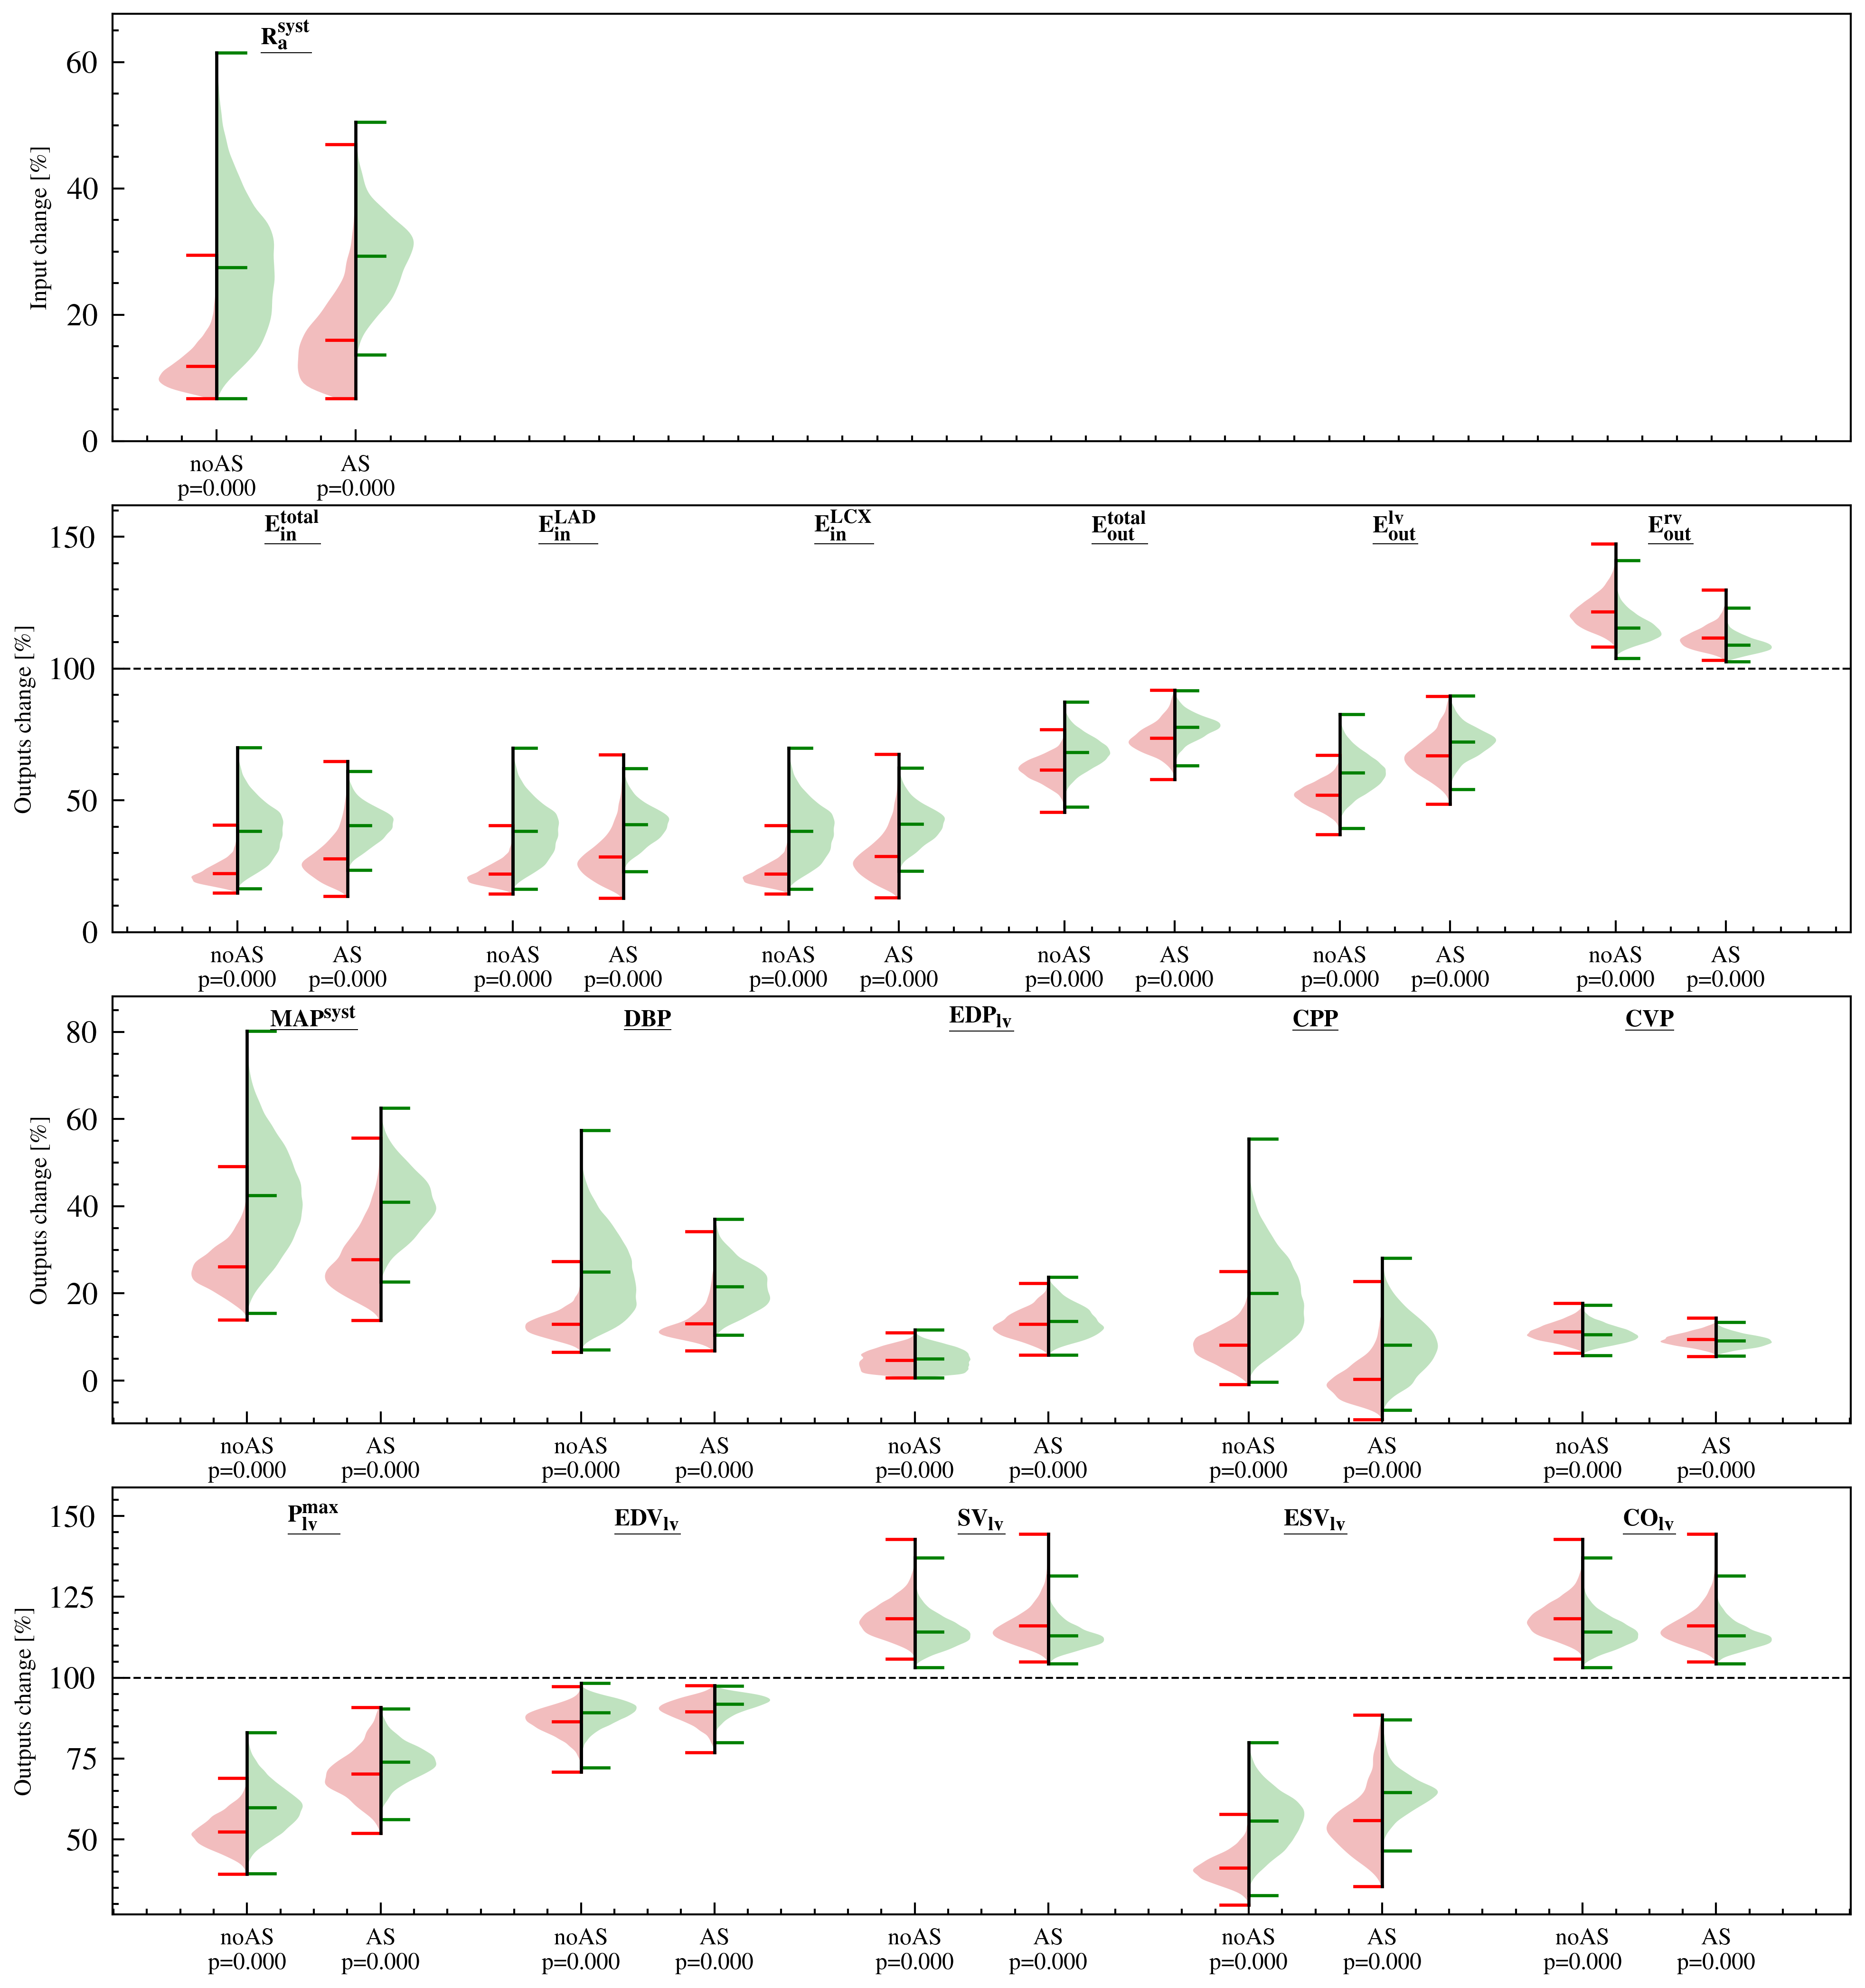

In [ ]:
# simulation 1
input_df_noAS = input_sim1_noAS.sort_values(by="Patient_ID")
input_df_AS = input_sim1_AS.sort_values(by="Patient_ID")
output_df_noAS = output_sim1_noAS.sort_values(by="Patient_ID")
output_df_AS = output_sim1_AS.sort_values(by="Patient_ID")
input_df_selpop_noAS = input_selpopulation_noAS.sort_values(by="Patient_ID")
input_df_selpop_AS = input_selpopulation_AS.sort_values(by="Patient_ID")
output_df_selpop_noAS = output_selpopulation_noAS.sort_values(by="Patient_ID")
output_df_selpop_AS = output_selpopulation_AS.sort_values(by="Patient_ID")

CENTIMETERS = 1/2.54
COLOR_BALANCED = "#2ca02c"
COLOR_IMBALANCE = "#d62728"

fig = plt.figure(figsize=(20*CENTIMETERS, 5.5*4*CENTIMETERS))

gs = fig.add_gridspec(4, 12, wspace=3.3, hspace=0.15)

axs = []
axs.append(fig.add_subplot(gs[0, 0:12]))

axs.append(fig.add_subplot(gs[1, 0:12])) 
axs.append(fig.add_subplot(gs[2, 0:12])) 
axs.append(fig.add_subplot(gs[3, 0:12])) 

percent_df_input_noAS = deepcopy(input_df_noAS)
percent_df_input_AS = deepcopy(input_df_AS)
keys = ["Ra_syst"]
keys_labels = [
    r"$\underline{\mathbf{R_{a}^{syst}}}$"
]
for key in keys:
    percent_df_input_noAS[key] = 100*input_df_noAS[key].values / input_df_selpop_noAS[key].values
    percent_df_input_AS[key] = 100*input_df_AS[key].values / input_df_selpop_AS[key].values


merged_noAS = percent_df_input_noAS.merge(output_df_noAS[["Patient_ID", "DeltaE"]], on="Patient_ID")
merged_AS = percent_df_input_AS.merge(output_df_AS[["Patient_ID", "DeltaE"]], on="Patient_ID")



ax = axs[0]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    # --- Imbalanced Data (Low Side) ---
    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Input change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
ax.set_xlim(-0.45, 7.05)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Ein", "Ein_LAD", "Ein_LCX", "VO2_total", "VO2_lv", "VO2_rv"]
keys_labels = [
    r"$\underline{\mathbf{E_{in}^{total}}}$", 
    r"$\underline{\mathbf{E_{in}^{LAD}}}$", 
    r"$\underline{\mathbf{E_{in}^{LCX}}}$", 
    r"$\underline{\mathbf{E_{out}^{total}}}$", 
    r"$\underline{\mathbf{E_{out}^{lv}}}$",
    r"$\underline{\mathbf{E_{out}^{rv}}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS

ax = axs[1]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Pa_syst_mean", "Pa_syst_min", "EDP_lv", "CPP", "Pv_syst_mean"]

keys_labels = [
    r"$\underline{\mathbf{MAP^{syst}}}$", 
    r"$\underline{\mathbf{DBP}}$", 
    r"$\underline{\mathbf{EDP_{lv}}}$", 
    r"$\underline{\mathbf{CPP}}$", 
    r"$\underline{\mathbf{CVP}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values

ax = axs[2]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(ymin*1.1, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Plv_max", "Vlv_max", "Vav", "Vlv_min", "CO_lv"]

keys_labels = [
    r"$\underline{\mathbf{P_{lv}^{max}}}$",
    r"$\underline{\mathbf{EDV_{lv}}}$", 
    r"$\underline{\mathbf{SV_{lv}}}$", 
    r"$\underline{\mathbf{ESV_{lv}}}$",
    r"$\underline{\mathbf{CO_{lv}}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS



ax = axs[3]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(ymin*0.9, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)





for ax in axs:
    ax.axhline(100, color="black", linestyle="--", linewidth=0.5)


#plt.savefig("obrázky/percentual_sim1.svg")
plt.savefig("Figures/percentual_sim1.png", dpi=400)


plt.show()


6.6


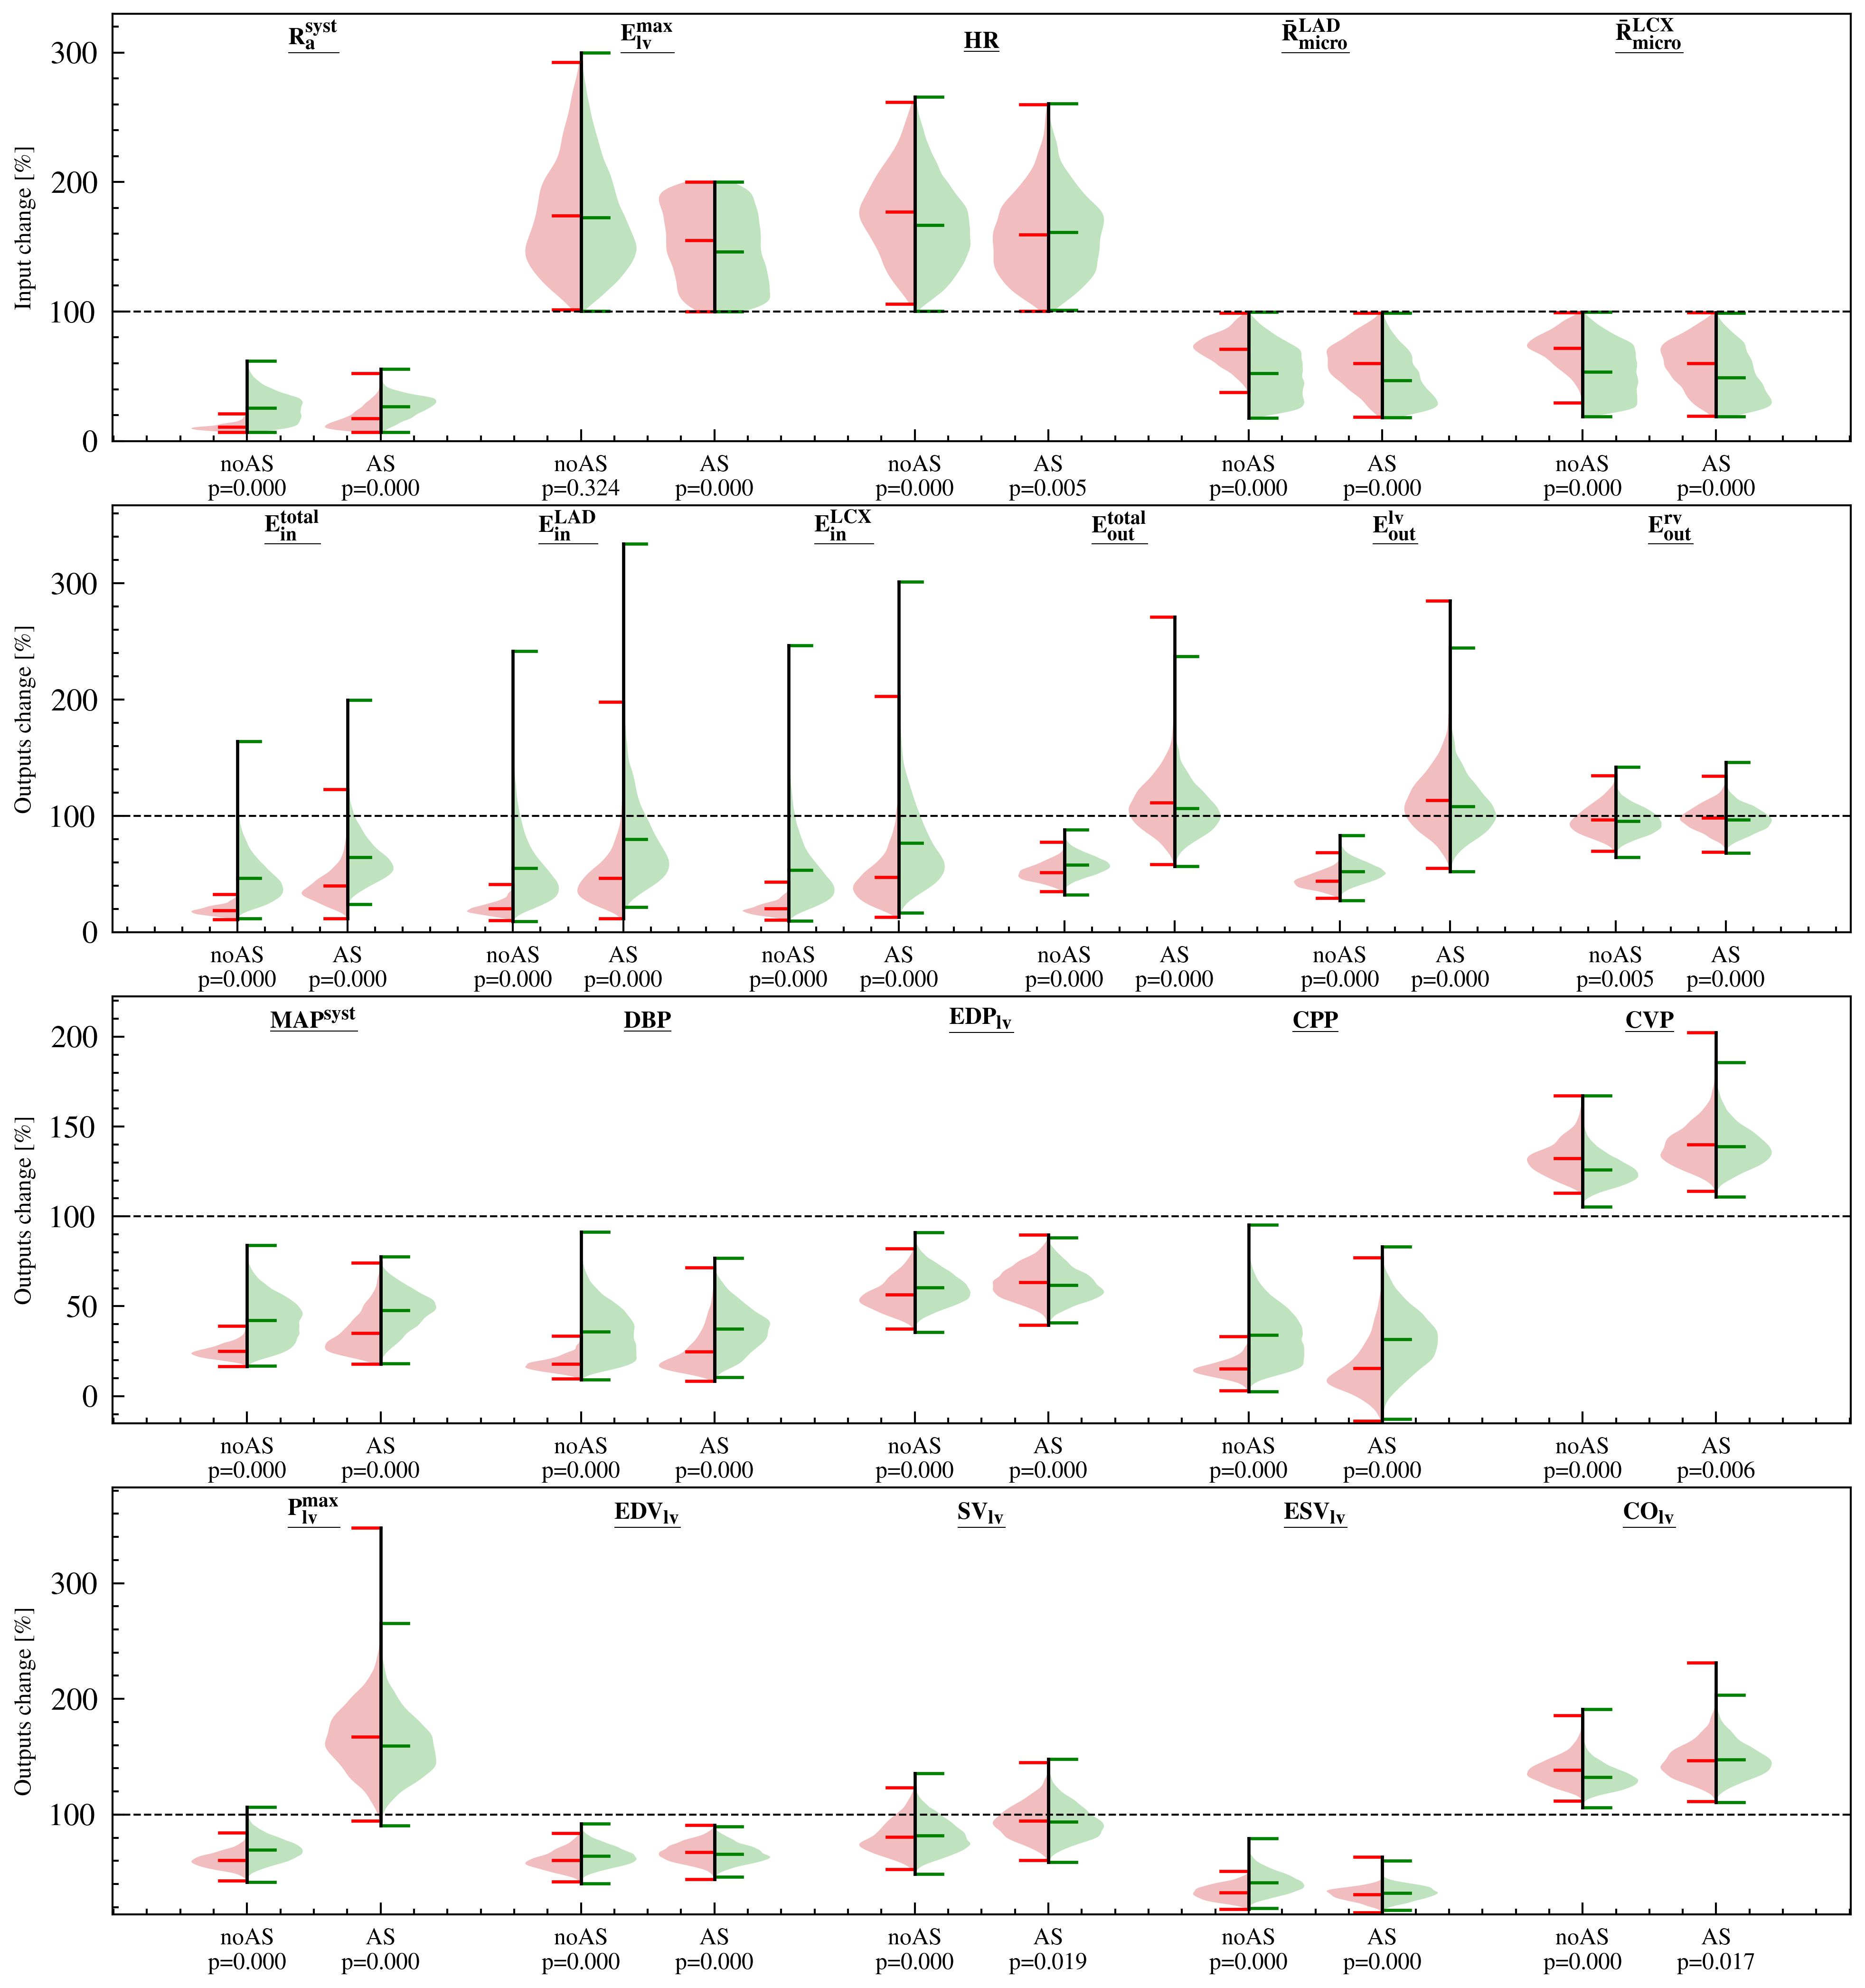

In [ ]:
# simulation 2
input_df_noAS = input_sim2_noAS.sort_values(by="Patient_ID")
input_df_AS = input_sim2_AS.sort_values(by="Patient_ID")
output_df_noAS = output_sim2_noAS.sort_values(by="Patient_ID")
output_df_AS = output_sim2_AS.sort_values(by="Patient_ID")
input_df_selpop_noAS = input_selpopulation_noAS.sort_values(by="Patient_ID")
input_df_selpop_AS = input_selpopulation_AS.sort_values(by="Patient_ID")
output_df_selpop_noAS = output_selpopulation_noAS.sort_values(by="Patient_ID")
output_df_selpop_AS = output_selpopulation_AS.sort_values(by="Patient_ID")

CENTIMETERS = 1/2.54
COLOR_BALANCED = "#2ca02c"
COLOR_IMBALANCE = "#d62728"

fig = plt.figure(figsize=(20*CENTIMETERS, 5.5*4*CENTIMETERS))

gs = fig.add_gridspec(4, 12, wspace=3.3, hspace=0.15)

axs = []
axs.append(fig.add_subplot(gs[0, 0:12]))

axs.append(fig.add_subplot(gs[1, 0:12])) # Larger
axs.append(fig.add_subplot(gs[2, 0:12])) # Larger
axs.append(fig.add_subplot(gs[3, 0:12])) # Larger

percent_df_input_noAS = deepcopy(input_df_noAS)
percent_df_input_AS = deepcopy(input_df_AS)
keys = ["Ra_syst", "Emax_lv", "HR", "Rmicro_max_LAD", "Rmicro_max_LCX"]
keys_labels = [
    r"$\underline{\mathbf{R_{a}^{syst}}}$",
    r"$\underline{\mathbf{E_{lv}^{max}}}$",
    r"$\underline{\mathbf{HR}}$",
    r"$\underline{\mathbf{\bar{R}_{micro}^{LAD}}}$",
    r"$\underline{\mathbf{\bar{R}_{micro}^{LCX}}}$"
]
for key in keys:
    percent_df_input_noAS[key] = 100*input_df_noAS[key].values / input_df_selpop_noAS[key].values
    percent_df_input_AS[key] = 100*input_df_AS[key].values / input_df_selpop_AS[key].values


merged_noAS = percent_df_input_noAS.merge(output_df_noAS[["Patient_ID", "DeltaE"]], on="Patient_ID")
merged_AS = percent_df_input_AS.merge(output_df_AS[["Patient_ID", "DeltaE"]], on="Patient_ID")



ax = axs[0]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Input change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
print(x_vp2-1.5)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Ein", "Ein_LAD", "Ein_LCX", "VO2_total", "VO2_lv", "VO2_rv"]
keys_labels = [
    r"$\underline{\mathbf{E_{in}^{total}}}$", 
    r"$\underline{\mathbf{E_{in}^{LAD}}}$", 
    r"$\underline{\mathbf{E_{in}^{LCX}}}$", 
    r"$\underline{\mathbf{E_{out}^{total}}}$", 
    r"$\underline{\mathbf{E_{out}^{lv}}}$",
    r"$\underline{\mathbf{E_{out}^{rv}}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS

ax = axs[1]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Pa_syst_mean", "Pa_syst_min", "EDP_lv", "CPP", "Pv_syst_mean"]

keys_labels = [
    r"$\underline{\mathbf{MAP^{syst}}}$", 
    r"$\underline{\mathbf{DBP}}$", 
    r"$\underline{\mathbf{EDP_{lv}}}$", 
    r"$\underline{\mathbf{CPP}}$", 
    r"$\underline{\mathbf{CVP}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS



ax = axs[2]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(ymin*1.1, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Plv_max", "Vlv_max", "Vav", "Vlv_min", "CO_lv"]

keys_labels = [
    r"$\underline{\mathbf{P_{lv}^{max}}}$",
    r"$\underline{\mathbf{EDV_{lv}}}$", 
    r"$\underline{\mathbf{SV_{lv}}}$", 
    r"$\underline{\mathbf{ESV_{lv}}}$",
    r"$\underline{\mathbf{CO_{lv}}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS



ax = axs[3]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(ymin*0.9, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)





for ax in axs:
    ax.axhline(100, color="black", linestyle="--", linewidth=0.5)


#plt.savefig("obrázky/percentual_sim2.svg")
plt.savefig("Figures/percentual_sim2.png", dpi=400)


plt.show()


6.6


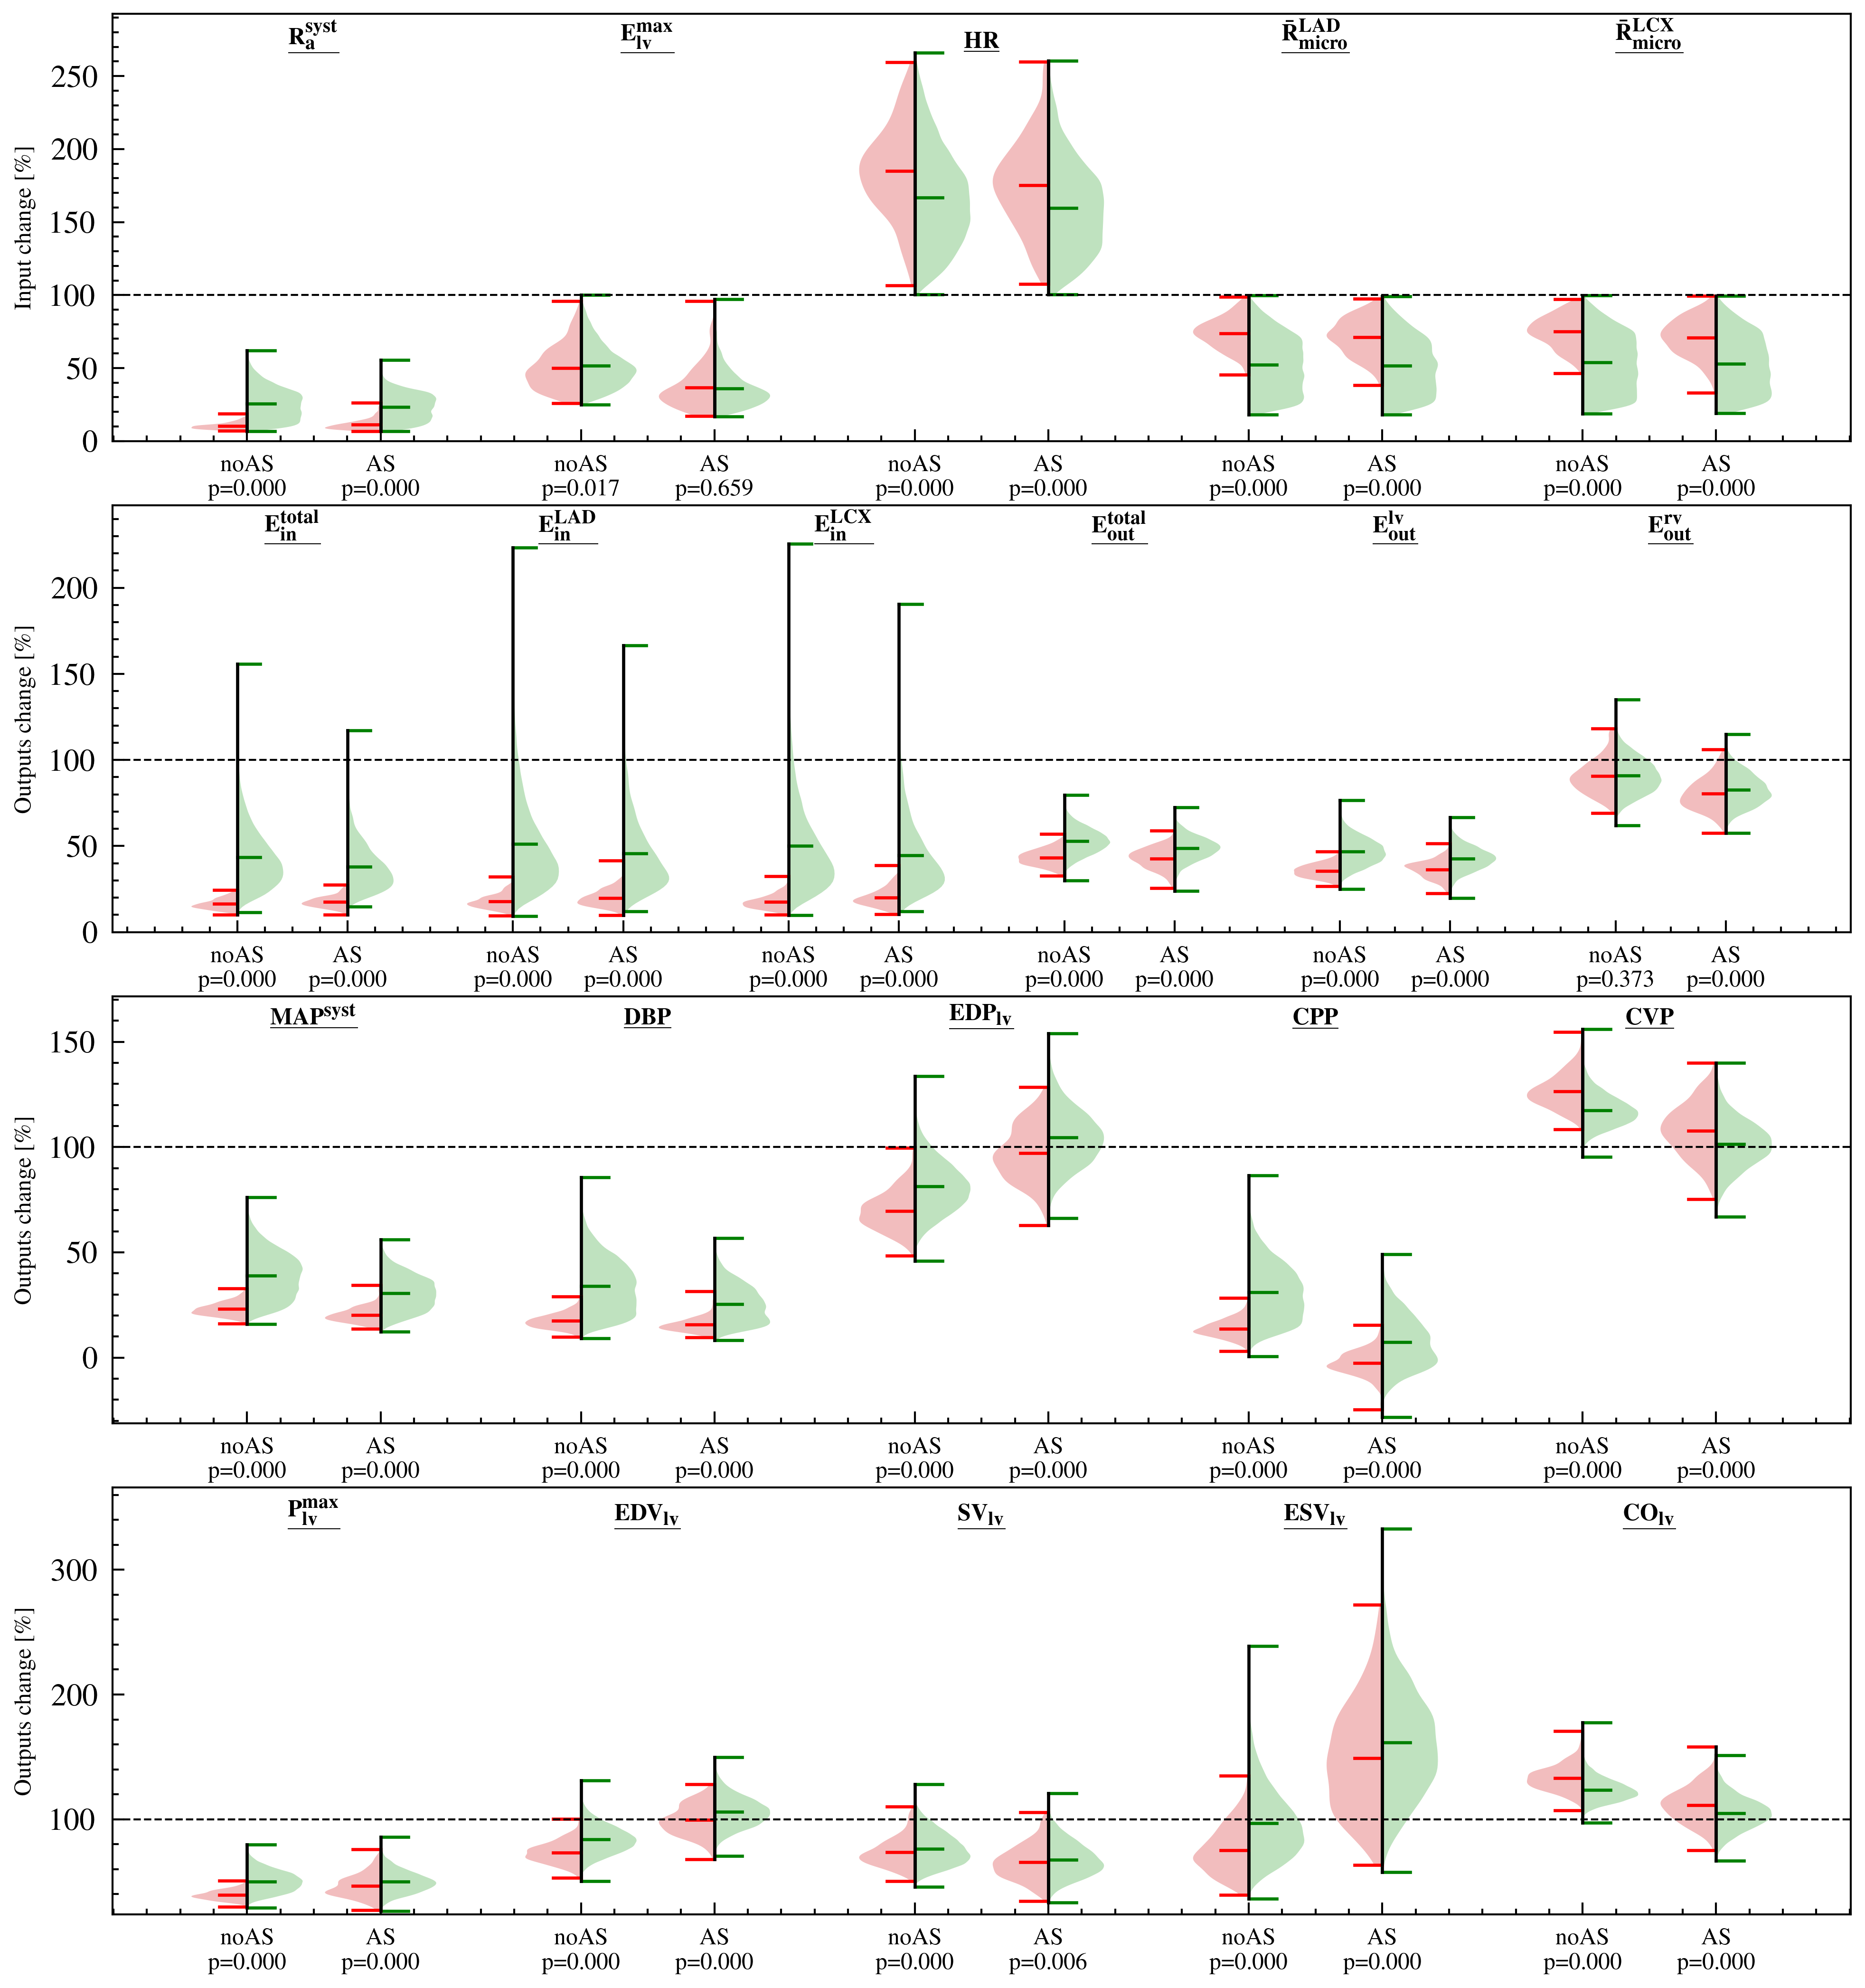

In [ ]:
# simulation 3
input_df_noAS = input_sim3_noAS.sort_values(by="Patient_ID")
input_df_AS = input_sim3_AS.sort_values(by="Patient_ID")
output_df_noAS = output_sim3_noAS.sort_values(by="Patient_ID")
output_df_AS = output_sim3_AS.sort_values(by="Patient_ID")
input_df_selpop_noAS = input_selpopulation_noAS.sort_values(by="Patient_ID")
input_df_selpop_AS = input_selpopulation_AS.sort_values(by="Patient_ID")
output_df_selpop_noAS = output_selpopulation_noAS.sort_values(by="Patient_ID")
output_df_selpop_AS = output_selpopulation_AS.sort_values(by="Patient_ID")

CENTIMETERS = 1/2.54
COLOR_BALANCED = "#2ca02c"
COLOR_IMBALANCE = "#d62728"

fig = plt.figure(figsize=(20*CENTIMETERS, 5.5*4*CENTIMETERS))

gs = fig.add_gridspec(4, 12, wspace=3.3, hspace=0.15)

axs = []
axs.append(fig.add_subplot(gs[0, 0:12]))

axs.append(fig.add_subplot(gs[1, 0:12])) # Larger
axs.append(fig.add_subplot(gs[2, 0:12])) # Larger
axs.append(fig.add_subplot(gs[3, 0:12])) # Larger

percent_df_input_noAS = deepcopy(input_df_noAS)
percent_df_input_AS = deepcopy(input_df_AS)
keys = ["Ra_syst", "Emax_lv", "HR", "Rmicro_max_LAD", "Rmicro_max_LCX"]
keys_labels = [
    r"$\underline{\mathbf{R_{a}^{syst}}}$",
    r"$\underline{\mathbf{E_{lv}^{max}}}$",
    r"$\underline{\mathbf{HR}}$",
    r"$\underline{\mathbf{\bar{R}_{micro}^{LAD}}}$",
    r"$\underline{\mathbf{\bar{R}_{micro}^{LCX}}}$"
]
for key in keys:
    percent_df_input_noAS[key] = 100*input_df_noAS[key].values / input_df_selpop_noAS[key].values
    percent_df_input_AS[key] = 100*input_df_AS[key].values / input_df_selpop_AS[key].values


merged_noAS = percent_df_input_noAS.merge(output_df_noAS[["Patient_ID", "DeltaE"]], on="Patient_ID")
merged_AS = percent_df_input_AS.merge(output_df_AS[["Patient_ID", "DeltaE"]], on="Patient_ID")



ax = axs[0]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Input change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
print(x_vp2-1.5)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Ein", "Ein_LAD", "Ein_LCX", "VO2_total", "VO2_lv", "VO2_rv"]
keys_labels = [
    r"$\underline{\mathbf{E_{in}^{total}}}$", 
    r"$\underline{\mathbf{E_{in}^{LAD}}}$", 
    r"$\underline{\mathbf{E_{in}^{LCX}}}$", 
    r"$\underline{\mathbf{E_{out}^{total}}}$", 
    r"$\underline{\mathbf{E_{out}^{lv}}}$",
    r"$\underline{\mathbf{E_{out}^{rv}}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS

ax = axs[1]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Pa_syst_mean", "Pa_syst_min", "EDP_lv", "CPP", "Pv_syst_mean"]

keys_labels = [
    r"$\underline{\mathbf{MAP^{syst}}}$", 
    r"$\underline{\mathbf{DBP}}$", 
    r"$\underline{\mathbf{EDP_{lv}}}$", 
    r"$\underline{\mathbf{CPP}}$", 
    r"$\underline{\mathbf{CVP}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS



ax = axs[2]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    # --- Imbalanced Data (Low Side) ---
    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(ymin*1.1, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Plv_max", "Vlv_max", "Vav", "Vlv_min", "CO_lv"]

keys_labels = [
    r"$\underline{\mathbf{P_{lv}^{max}}}$",
    r"$\underline{\mathbf{EDV_{lv}}}$", 
    r"$\underline{\mathbf{SV_{lv}}}$", 
    r"$\underline{\mathbf{ESV_{lv}}}$",
    r"$\underline{\mathbf{CO_{lv}}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS



ax = axs[3]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key])
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key])
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(ymin*0.9, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)




for ax in axs:
    ax.axhline(100, color="black", linestyle="--", linewidth=0.5)



#plt.savefig("obrázky/percentual_sim3.svg")
plt.savefig("Figures/percentual_sim3.png", dpi=400)


plt.show()


6.6


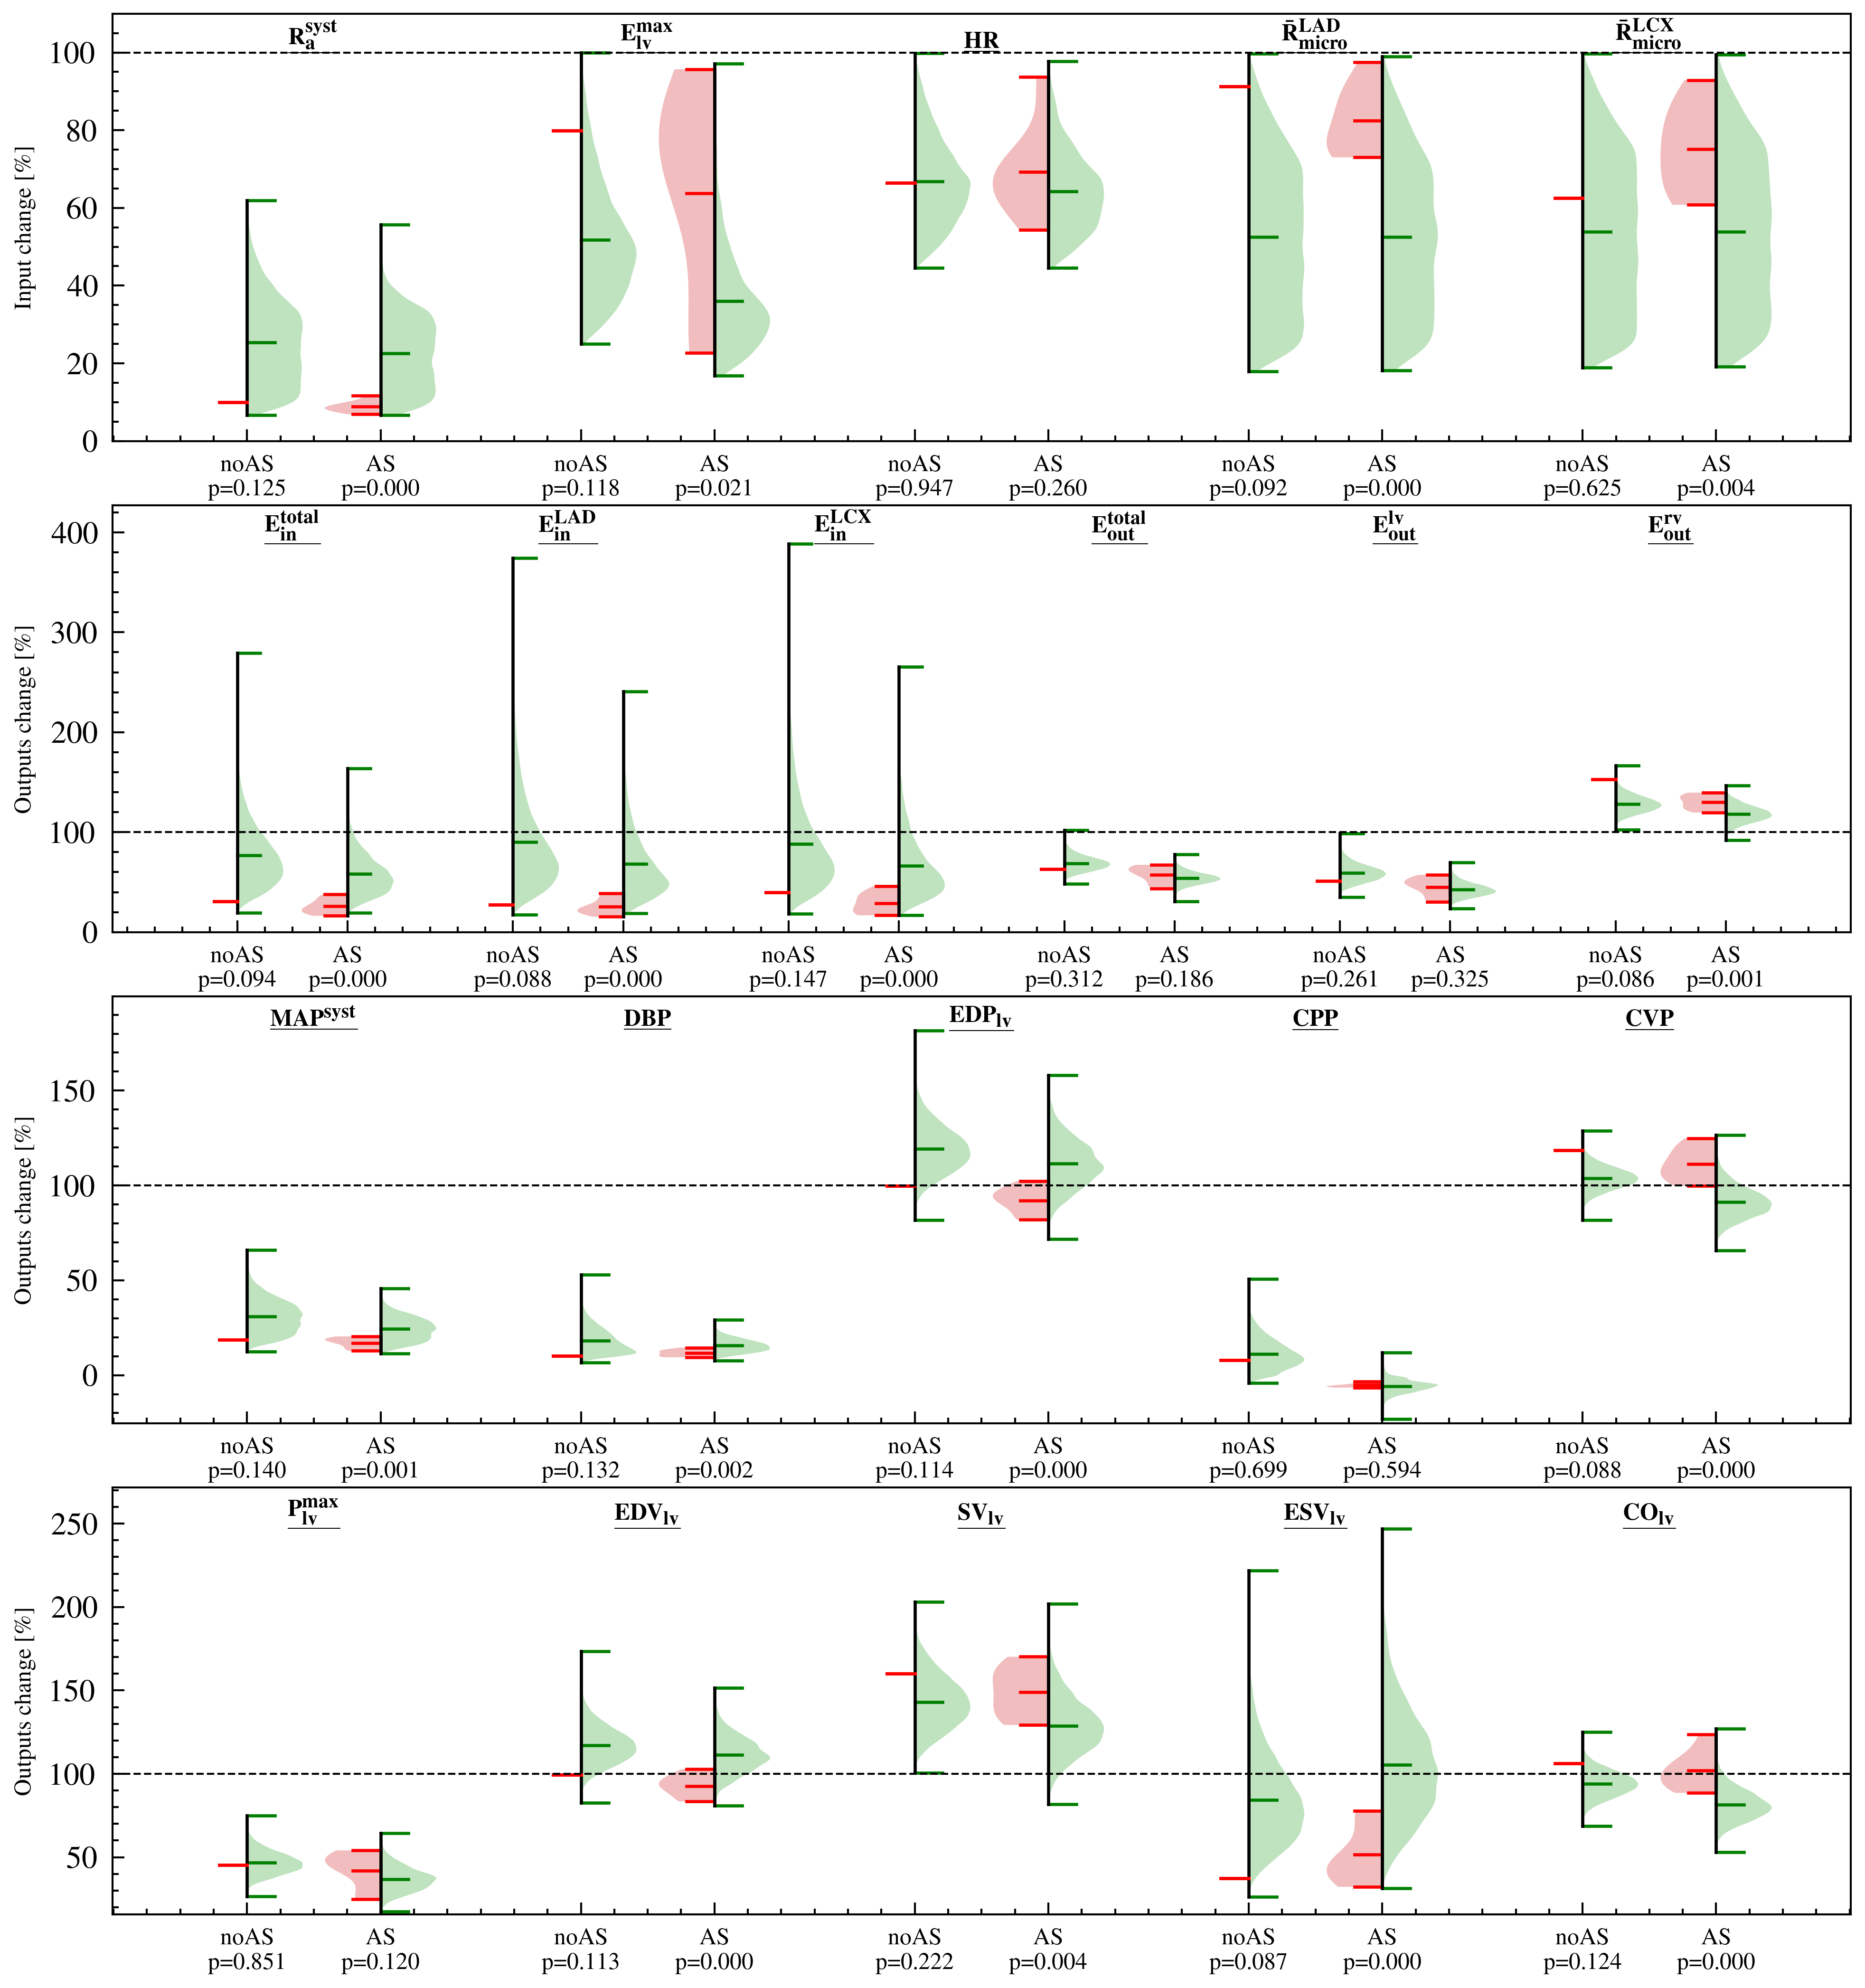

In [11]:
# simulation 4
input_df_noAS = input_sim4_noAS.sort_values(by="Patient_ID")
input_df_AS = input_sim4_AS.sort_values(by="Patient_ID")
output_df_noAS = output_sim4_noAS.sort_values(by="Patient_ID")
output_df_AS = output_sim4_AS.sort_values(by="Patient_ID")
input_df_selpop_noAS = input_selpopulation_noAS.sort_values(by="Patient_ID")
input_df_selpop_AS = input_selpopulation_AS.sort_values(by="Patient_ID")
output_df_selpop_noAS = output_selpopulation_noAS.sort_values(by="Patient_ID")
output_df_selpop_AS = output_selpopulation_AS.sort_values(by="Patient_ID")

CENTIMETERS = 1/2.54
COLOR_BALANCED = "#2ca02c"
COLOR_IMBALANCE = "#d62728"

fig = plt.figure(figsize=(20*CENTIMETERS, 5.5*4*CENTIMETERS))

gs = fig.add_gridspec(4, 12, wspace=3.3, hspace=0.15)

axs = []
axs.append(fig.add_subplot(gs[0, 0:12]))

axs.append(fig.add_subplot(gs[1, 0:12])) # Larger
axs.append(fig.add_subplot(gs[2, 0:12])) # Larger
axs.append(fig.add_subplot(gs[3, 0:12])) # Larger

percent_df_input_noAS = deepcopy(input_df_noAS)
percent_df_input_AS = deepcopy(input_df_AS)
keys = ["Ra_syst", "Emax_lv", "HR", "Rmicro_max_LAD", "Rmicro_max_LCX"]
keys_labels = [
    r"$\underline{\mathbf{R_{a}^{syst}}}$",
    r"$\underline{\mathbf{E_{lv}^{max}}}$",
    r"$\underline{\mathbf{HR}}$",
    r"$\underline{\mathbf{\bar{R}_{micro}^{LAD}}}$",
    r"$\underline{\mathbf{\bar{R}_{micro}^{LCX}}}$"
]
for key in keys:
    percent_df_input_noAS[key] = 100*input_df_noAS[key].values / input_df_selpop_noAS[key].values
    percent_df_input_AS[key] = 100*input_df_AS[key].values / input_df_selpop_AS[key].values


merged_noAS = percent_df_input_noAS.merge(output_df_noAS[["Patient_ID", "DeltaE"]], on="Patient_ID")
merged_AS = percent_df_input_AS.merge(output_df_AS[["Patient_ID", "DeltaE"]], on="Patient_ID")



ax = axs[0]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key], method="asymptotic")
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key], method="asymptotic")
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Input change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
print(x_vp2-1.5)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Ein", "Ein_LAD", "Ein_LCX", "VO2_total", "VO2_lv", "VO2_rv"]
keys_labels = [
    r"$\underline{\mathbf{E_{in}^{total}}}$", 
    r"$\underline{\mathbf{E_{in}^{LAD}}}$", 
    r"$\underline{\mathbf{E_{in}^{LCX}}}$", 
    r"$\underline{\mathbf{E_{out}^{total}}}$", 
    r"$\underline{\mathbf{E_{out}^{lv}}}$",
    r"$\underline{\mathbf{E_{out}^{rv}}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS

ax = axs[1]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key], method="asymptotic")
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key], method="asymptotic")
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Pa_syst_mean", "Pa_syst_min", "EDP_lv", "CPP", "Pv_syst_mean"]

keys_labels = [
    r"$\underline{\mathbf{MAP^{syst}}}$", 
    r"$\underline{\mathbf{DBP}}$", 
    r"$\underline{\mathbf{EDP_{lv}}}$", 
    r"$\underline{\mathbf{CPP}}$", 
    r"$\underline{\mathbf{CVP}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS



ax = axs[2]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key], method="asymptotic")
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key], method="asymptotic")
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(ymin*1.1, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

percent_df_output_noAS = deepcopy(output_df_noAS)
percent_df_output_AS = deepcopy(output_df_AS)
keys = ["Plv_max", "Vlv_max", "Vav", "Vlv_min", "CO_lv"]

keys_labels = [
    r"$\underline{\mathbf{P_{lv}^{max}}}$",
    r"$\underline{\mathbf{EDV_{lv}}}$", 
    r"$\underline{\mathbf{SV_{lv}}}$", 
    r"$\underline{\mathbf{ESV_{lv}}}$",
    r"$\underline{\mathbf{CO_{lv}}}$"
]

for key in keys:
    percent_df_output_noAS[key] = 100*output_df_noAS[key].values / output_df_selpop_noAS[key].values
    percent_df_output_AS[key] = 100*output_df_AS[key].values / output_df_selpop_AS[key].values


merged_noAS = percent_df_output_noAS
merged_AS = percent_df_output_AS



ax = axs[3]

x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(merged_noAS[key].max(), merged_AS[key].max()) for key in keys])
ymin = min([min(merged_noAS[key].min(), merged_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [merged_noAS[merged_noAS["DeltaE"]>=0][key].values, merged_AS[merged_AS["DeltaE"]>=0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(merged_noAS[merged_noAS["DeltaE"]>=0][key], merged_noAS[merged_noAS["DeltaE"]<0][key], method="asymptotic")
    r_noAS = 1 - 2*u / (len(merged_noAS[merged_noAS["DeltaE"]>=0][key])*len(merged_noAS[merged_noAS["DeltaE"]<0][key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [merged_noAS[merged_noAS["DeltaE"]<0][key].values, merged_AS[merged_AS["DeltaE"]<0][key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(merged_AS[merged_AS["DeltaE"]>=0][key], merged_AS[merged_AS["DeltaE"]<0][key], method="asymptotic")
    r_AS = 1 - 2*u / (len(merged_AS[merged_AS["DeltaE"]>=0][key])*len(merged_AS[merged_AS["DeltaE"]<0][key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel(r"Outputs change [\%]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(ymin*0.9, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)




for ax in axs:
    ax.axhline(100, color="black", linestyle="--", linewidth=0.5)



#plt.savefig("obrázky/percentual_sim4.svg")
plt.savefig("Figures/percentual_sim4.png", dpi=400)


plt.show()


# VAC analysis

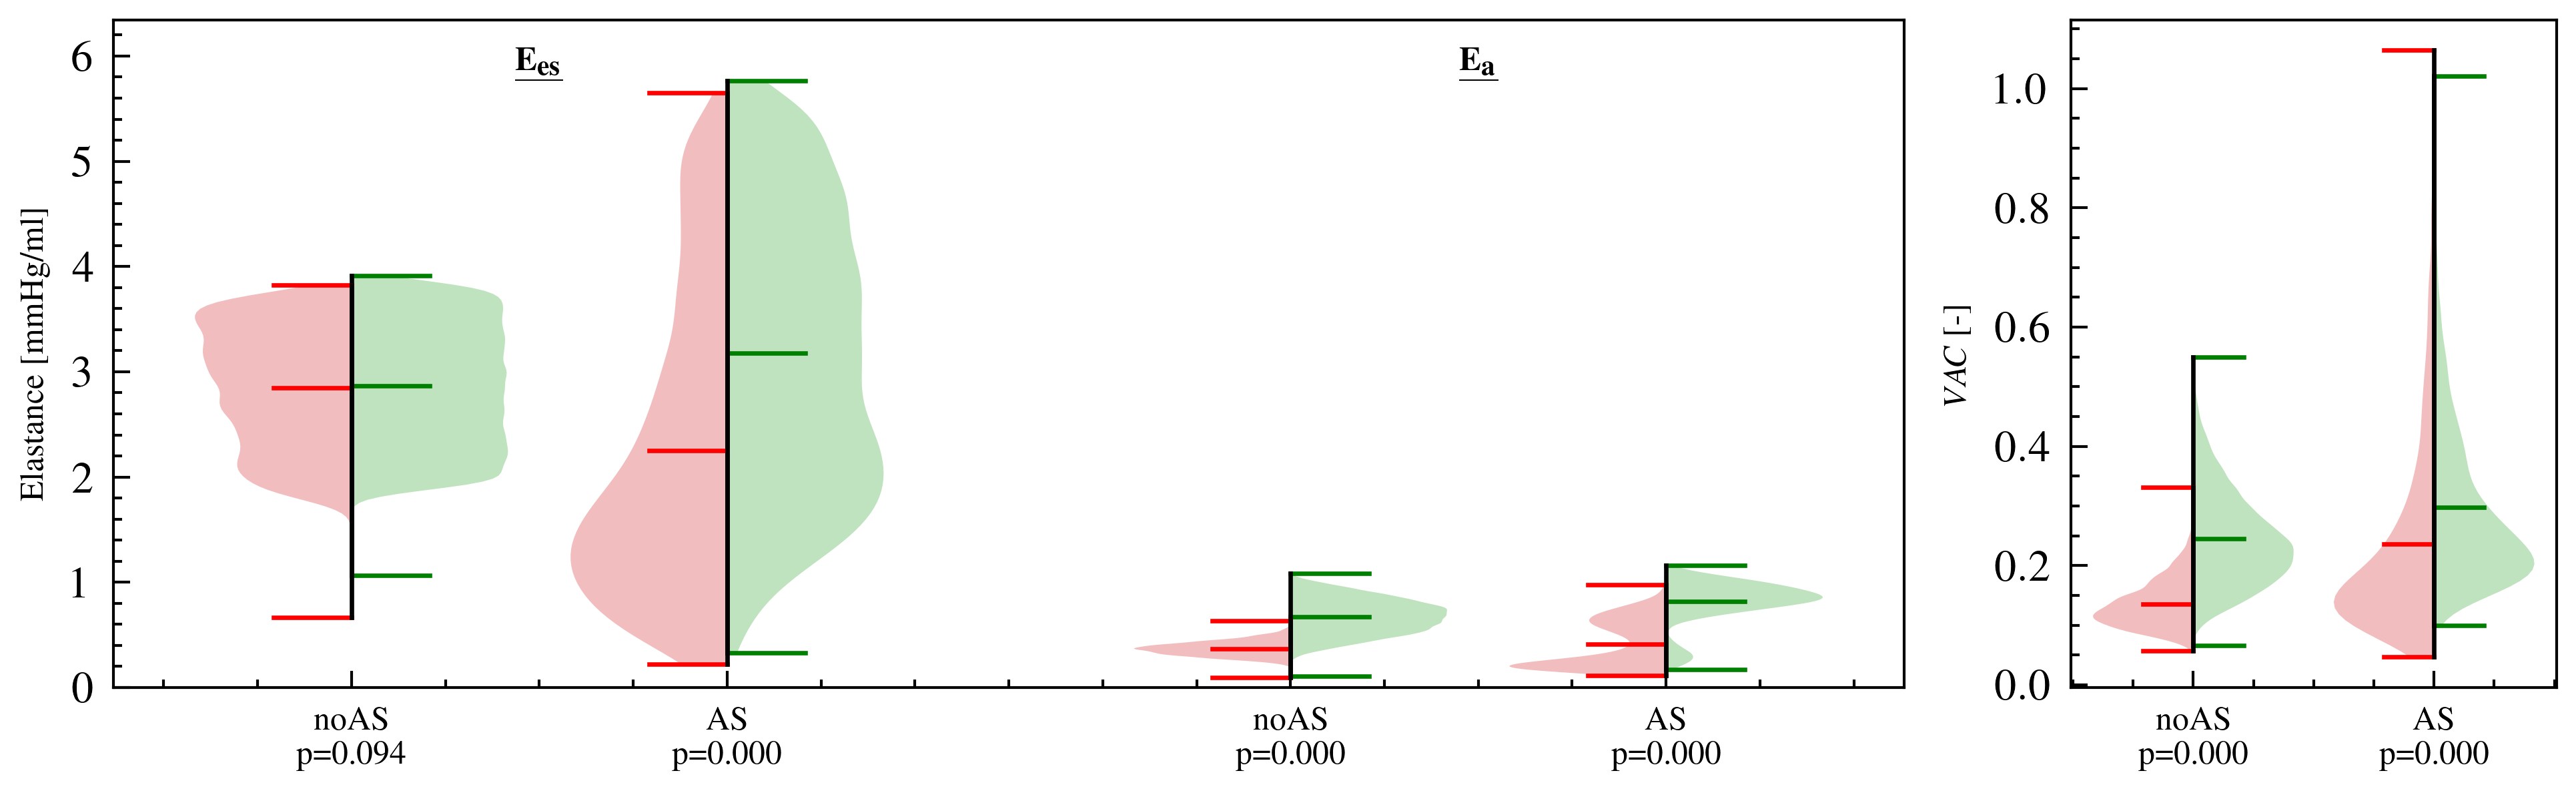

In [ ]:
# simulation 1
input_df_noAS = input_sim1_noAS
input_df_AS = input_sim1_AS
output_df_noAS = output_sim1_noAS
output_df_AS = output_sim1_AS

imbalanced_IDs_noAS = output_df_noAS[output_df_noAS["DeltaE"]<0]["Patient_ID"].tolist()
input_df_balanced_noAS = input_df_noAS[~input_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
input_df_imbalanced_noAS = input_df_noAS[input_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
output_df_balanced_noAS = output_df_noAS[~output_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
output_df_imbalanced_noAS = output_df_noAS[output_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]

imbalanced_IDs_AS = output_df_AS[output_df_AS["DeltaE"]<0]["Patient_ID"].tolist()
input_df_balanced_AS = input_df_AS[~input_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
input_df_imbalanced_AS = input_df_AS[input_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
output_df_balanced_AS = output_df_AS[~output_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
output_df_imbalanced_AS = output_df_AS[output_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]

CENTIMETERS = 1/2.54
COLOR_BALANCED = "#2ca02c"
COLOR_IMBALANCE = "#d62728"

fig = plt.figure(figsize=(20*CENTIMETERS, 5.5*1*CENTIMETERS))

gs = fig.add_gridspec(1, 12, wspace=3.3, hspace=0.15)

axs = []
axs.append(fig.add_subplot(gs[0, 0:9]))
axs.append(fig.add_subplot(gs[0, 9:12]))




ax = axs[0]
keys = ["Ees_lv", "Ea_lv"]
keys_labels = [
    r"$\underline{\mathbf{E_{es}}}$", 
    r"$\underline{\mathbf{E_{a}}}$"
]
x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(output_df_noAS[key].max(), output_df_AS[key].max()) for key in keys])
ymin = min([min(output_df_noAS[key].min(), output_df_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [output_df_balanced_noAS[key].values, output_df_balanced_AS[key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(output_df_balanced_noAS[key], output_df_imbalanced_noAS[key])
    r_noAS = 1 - 2*u / (len(output_df_balanced_noAS[key])*len(output_df_imbalanced_noAS[key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [output_df_imbalanced_noAS[key].values, output_df_imbalanced_AS[key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(output_df_balanced_AS[key], output_df_imbalanced_AS[key])
    r_AS = 1 - 2*u / (len(output_df_balanced_AS[key])*len(output_df_imbalanced_AS[key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel("Elastance [mmHg/ml]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

ax = axs[1]
key = "VAC_lv"
key_label = r"$VAC$"
x_vp1, x_vp2 = 0, 0.6
x_ticks_labels = []
x_ticks = []
data_plot = [output_df_balanced_noAS[key].values, output_df_balanced_AS[key].values]
vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
vp["bodies"][0].set_facecolor(COLOR_BALANCED)
vp["bodies"][1].set_facecolor(COLOR_BALANCED)
vp["cbars"].set_color("black")
u, p_value_noAS = mannwhitneyu(output_df_balanced_noAS[key], output_df_imbalanced_noAS[key])
r_noAS = 1 - 2*u / (len(output_df_balanced_noAS[key])*len(output_df_imbalanced_noAS[key]))
r_noAS = np.round(r_noAS,2)

data_plot = [output_df_imbalanced_noAS[key].values, output_df_imbalanced_AS[key].values]
vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
vp["cbars"].set_color("black")
u, p_value_AS = mannwhitneyu(output_df_balanced_AS[key], output_df_imbalanced_AS[key])
r_AS = 1 - 2*u / (len(output_df_balanced_AS[key])*len(output_df_imbalanced_AS[key]))
r_AS = np.round(r_AS,2)

x_ticks.append(x_vp1)
x_ticks.append(x_vp2)
x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
ax.set_ylabel(r"$VAC$ [-]", fontsize=6)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)


#plt.savefig("obrázky/VAC_sim1.svg")
plt.savefig("Figures/VAC_sim1.png", dpi=400)


plt.show()


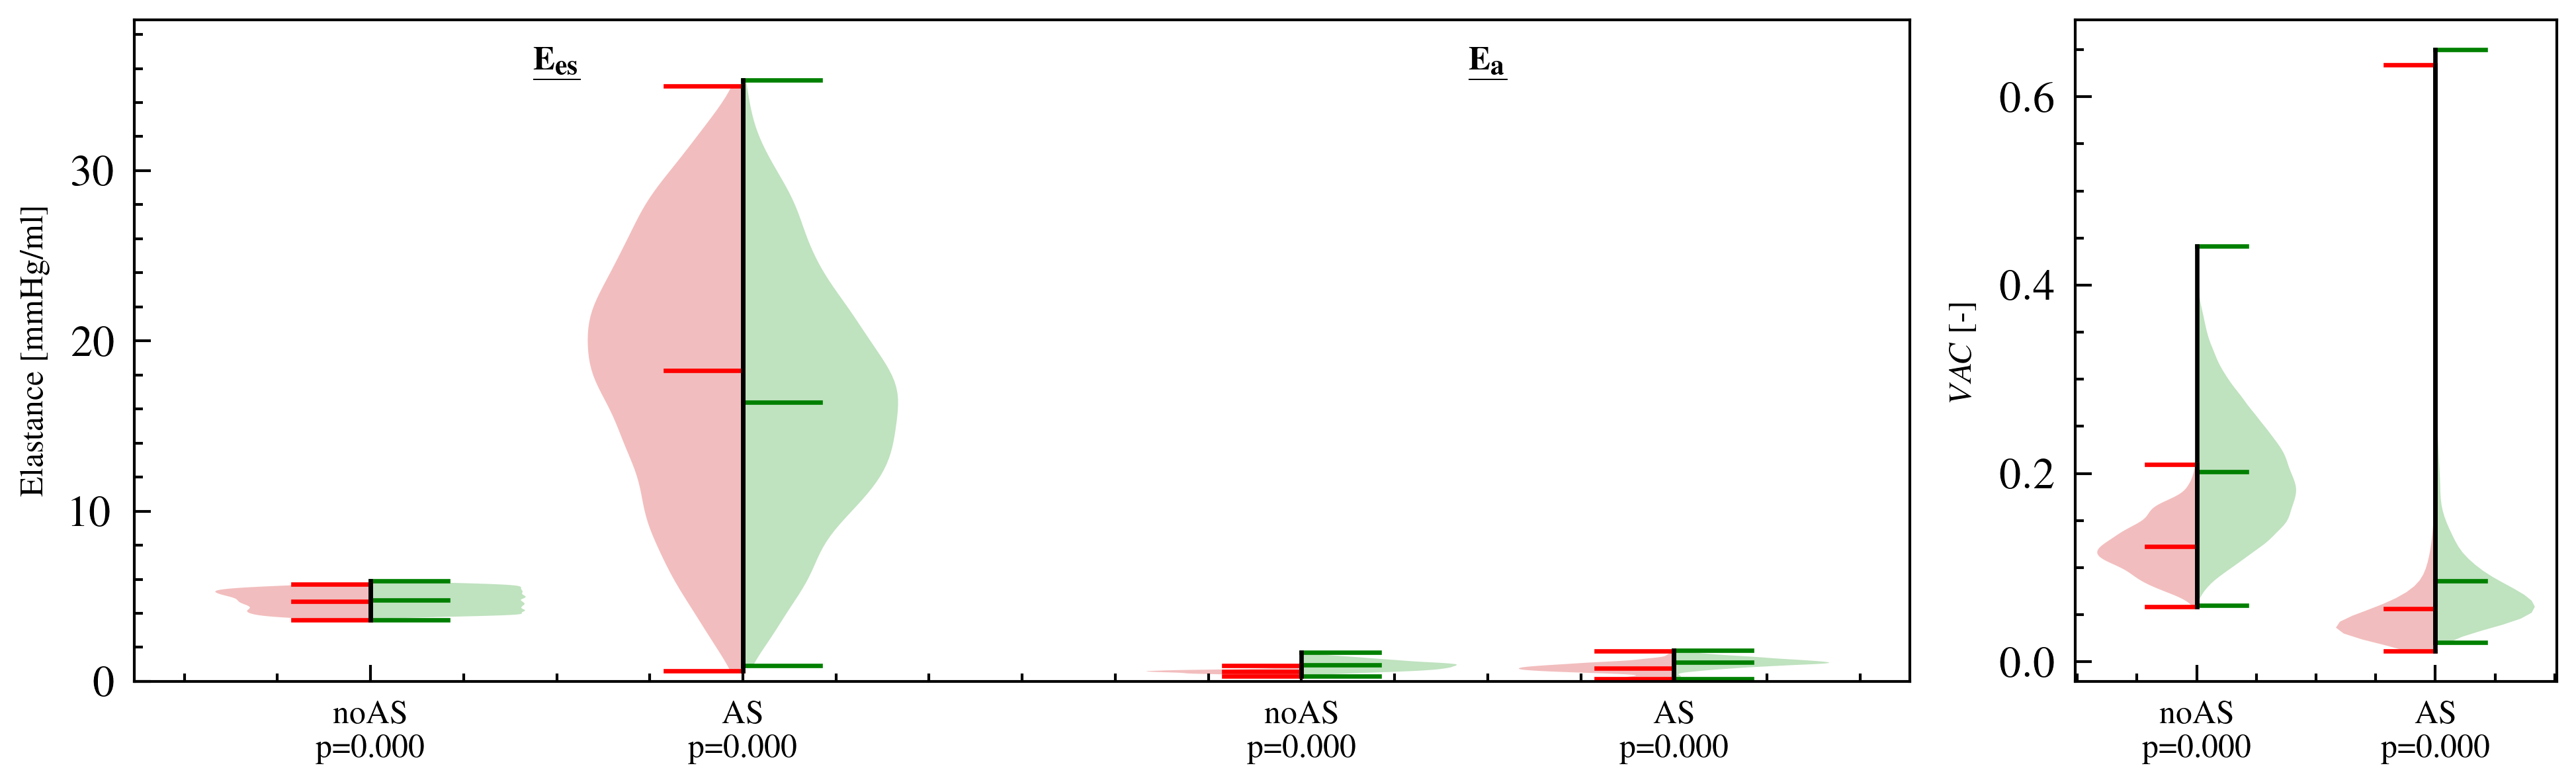

In [ ]:
# simulation 2
input_df_noAS = input_sim2_noAS
input_df_AS = input_sim2_AS
output_df_noAS = output_sim2_noAS
output_df_AS = output_sim2_AS

imbalanced_IDs_noAS = output_df_noAS[output_df_noAS["DeltaE"]<0]["Patient_ID"].tolist()
input_df_balanced_noAS = input_df_noAS[~input_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
input_df_imbalanced_noAS = input_df_noAS[input_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
output_df_balanced_noAS = output_df_noAS[~output_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
output_df_imbalanced_noAS = output_df_noAS[output_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]

imbalanced_IDs_AS = output_df_AS[output_df_AS["DeltaE"]<0]["Patient_ID"].tolist()
input_df_balanced_AS = input_df_AS[~input_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
input_df_imbalanced_AS = input_df_AS[input_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
output_df_balanced_AS = output_df_AS[~output_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
output_df_imbalanced_AS = output_df_AS[output_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]

CENTIMETERS = 1/2.54
COLOR_BALANCED = "#2ca02c"
COLOR_IMBALANCE = "#d62728"

fig = plt.figure(figsize=(20*CENTIMETERS, 5.5*1*CENTIMETERS))

gs = fig.add_gridspec(1, 12, wspace=3.3, hspace=0.15)

axs = []
axs.append(fig.add_subplot(gs[0, 0:9]))
axs.append(fig.add_subplot(gs[0, 9:12]))




ax = axs[0]
keys = ["Ees_lv", "Ea_lv"]
keys_labels = [
    r"$\underline{\mathbf{E_{es}}}$", 
    r"$\underline{\mathbf{E_{a}}}$"
]
x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(output_df_noAS[key].max(), output_df_AS[key].max()) for key in keys])
ymin = min([min(output_df_noAS[key].min(), output_df_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [output_df_balanced_noAS[key].values, output_df_balanced_AS[key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(output_df_balanced_noAS[key], output_df_imbalanced_noAS[key])
    r_noAS = 1 - 2*u / (len(output_df_balanced_noAS[key])*len(output_df_imbalanced_noAS[key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [output_df_imbalanced_noAS[key].values, output_df_imbalanced_AS[key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(output_df_balanced_AS[key], output_df_imbalanced_AS[key])
    r_AS = 1 - 2*u / (len(output_df_balanced_AS[key])*len(output_df_imbalanced_AS[key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel("Elastance [mmHg/ml]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

ax = axs[1]
key = "VAC_lv"
key_label = r"$VAC$"
x_vp1, x_vp2 = 0, 0.6
x_ticks_labels = []
x_ticks = []
data_plot = [output_df_balanced_noAS[key].values, output_df_balanced_AS[key].values]
vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
vp["bodies"][0].set_facecolor(COLOR_BALANCED)
vp["bodies"][1].set_facecolor(COLOR_BALANCED)
vp["cbars"].set_color("black")
u, p_value_noAS = mannwhitneyu(output_df_balanced_noAS[key], output_df_imbalanced_noAS[key])
r_noAS = 1 - 2*u / (len(output_df_balanced_noAS[key])*len(output_df_imbalanced_noAS[key]))
r_noAS = np.round(r_noAS,2)

data_plot = [output_df_imbalanced_noAS[key].values, output_df_imbalanced_AS[key].values]
vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
vp["cbars"].set_color("black")
u, p_value_AS = mannwhitneyu(output_df_balanced_AS[key], output_df_imbalanced_AS[key])
r_AS = 1 - 2*u / (len(output_df_balanced_AS[key])*len(output_df_imbalanced_AS[key]))
r_AS = np.round(r_AS,2)

x_ticks.append(x_vp1)
x_ticks.append(x_vp2)
x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
ax.set_ylabel(r"$VAC$ [-]", fontsize=6)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)


plt.savefig("Figures/VAC_sim2.png", dpi=400)


plt.show()


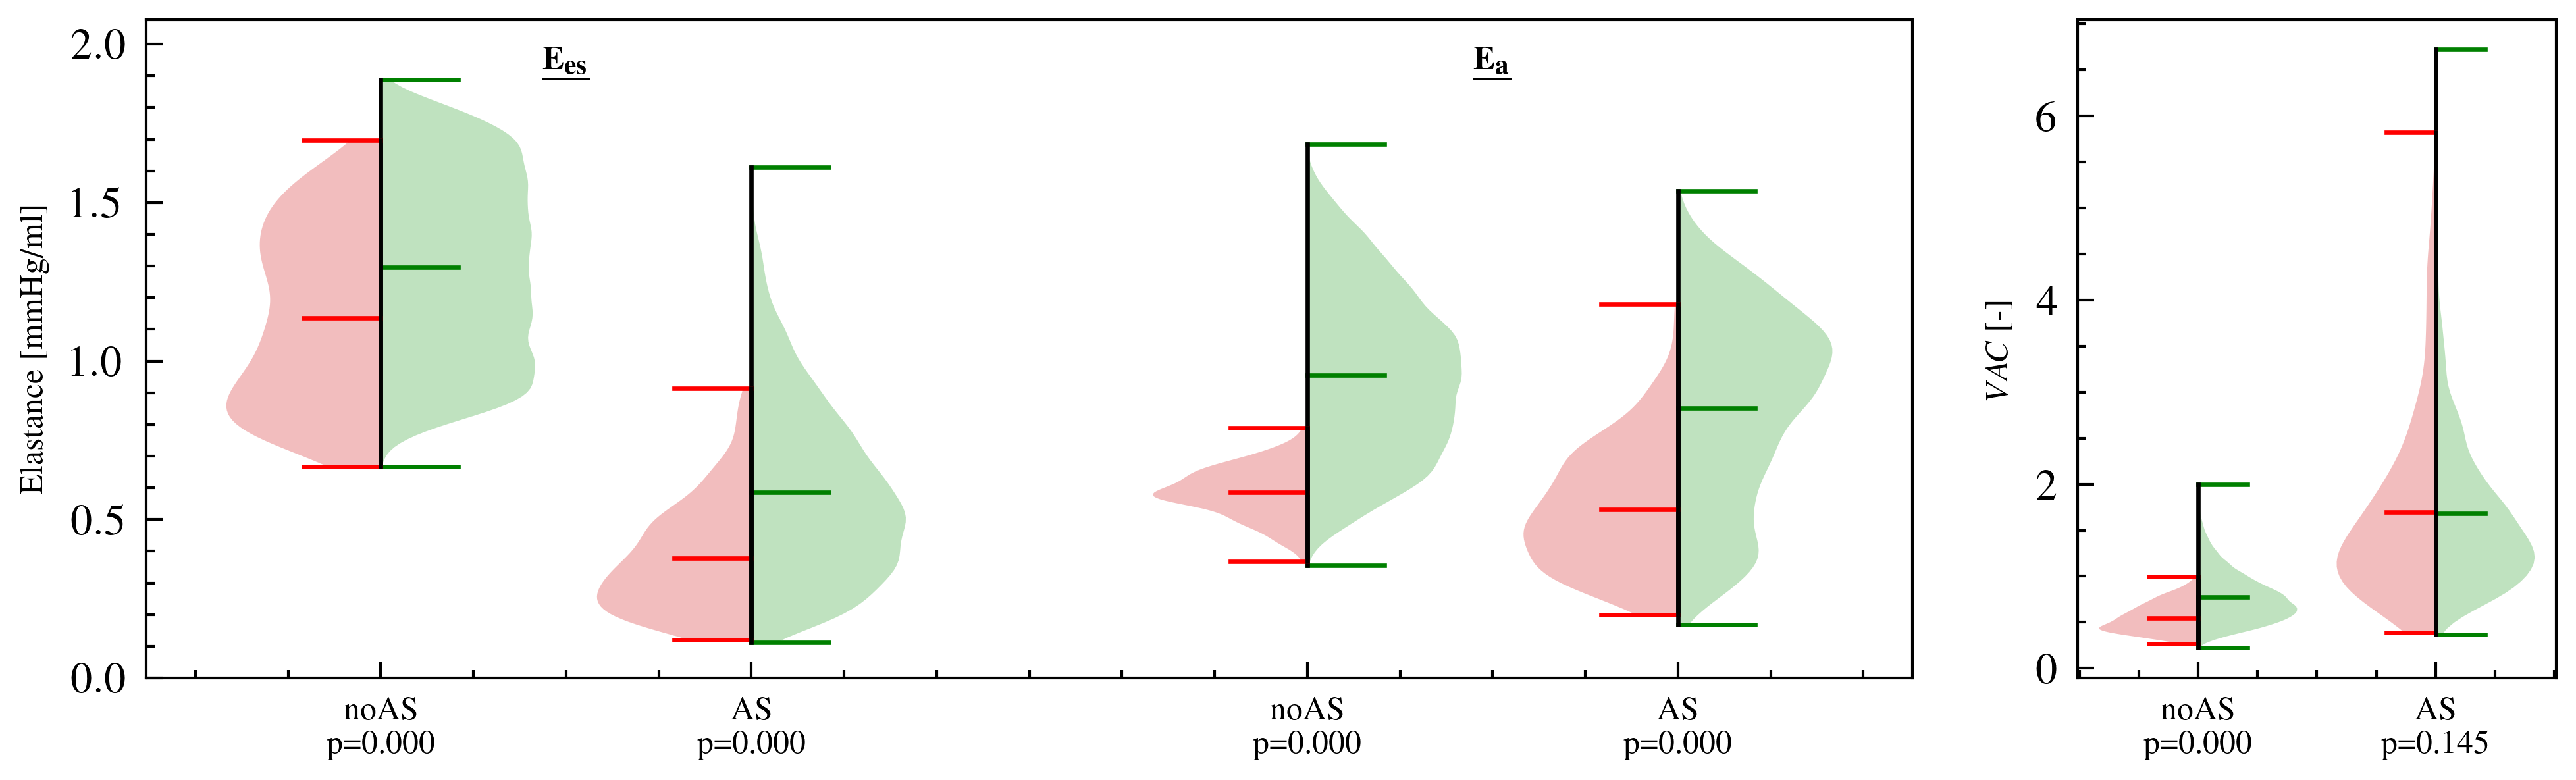

In [ ]:
# simulation 3
input_df_noAS = input_sim3_noAS
input_df_AS = input_sim3_AS
output_df_noAS = output_sim3_noAS
output_df_AS = output_sim3_AS

imbalanced_IDs_noAS = output_df_noAS[output_df_noAS["DeltaE"]<0]["Patient_ID"].tolist()
input_df_balanced_noAS = input_df_noAS[~input_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
input_df_imbalanced_noAS = input_df_noAS[input_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
output_df_balanced_noAS = output_df_noAS[~output_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
output_df_imbalanced_noAS = output_df_noAS[output_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]

imbalanced_IDs_AS = output_df_AS[output_df_AS["DeltaE"]<0]["Patient_ID"].tolist()
input_df_balanced_AS = input_df_AS[~input_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
input_df_imbalanced_AS = input_df_AS[input_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
output_df_balanced_AS = output_df_AS[~output_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
output_df_imbalanced_AS = output_df_AS[output_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]

CENTIMETERS = 1/2.54
COLOR_BALANCED = "#2ca02c"
COLOR_IMBALANCE = "#d62728"

fig = plt.figure(figsize=(20*CENTIMETERS, 5.5*1*CENTIMETERS))

gs = fig.add_gridspec(1, 12, wspace=3.3, hspace=0.15)

axs = []
axs.append(fig.add_subplot(gs[0, 0:9]))
axs.append(fig.add_subplot(gs[0, 9:12]))




ax = axs[0]
keys = ["Ees_lv", "Ea_lv"]
keys_labels = [
    r"$\underline{\mathbf{E_{es}}}$", 
    r"$\underline{\mathbf{E_{a}}}$"
]
x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(output_df_noAS[key].max(), output_df_AS[key].max()) for key in keys])
ymin = min([min(output_df_noAS[key].min(), output_df_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [output_df_balanced_noAS[key].values, output_df_balanced_AS[key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(output_df_balanced_noAS[key], output_df_imbalanced_noAS[key])
    r_noAS = 1 - 2*u / (len(output_df_balanced_noAS[key])*len(output_df_imbalanced_noAS[key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [output_df_imbalanced_noAS[key].values, output_df_imbalanced_AS[key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(output_df_balanced_AS[key], output_df_imbalanced_AS[key])
    r_AS = 1 - 2*u / (len(output_df_balanced_AS[key])*len(output_df_imbalanced_AS[key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel("Elastance [mmHg/ml]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

ax = axs[1]
key = "VAC_lv"
key_label = r"$VAC$"
x_vp1, x_vp2 = 0, 0.6
x_ticks_labels = []
x_ticks = []
data_plot = [output_df_balanced_noAS[key].values, output_df_balanced_AS[key].values]
vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
vp["bodies"][0].set_facecolor(COLOR_BALANCED)
vp["bodies"][1].set_facecolor(COLOR_BALANCED)
vp["cbars"].set_color("black")
u, p_value_noAS = mannwhitneyu(output_df_balanced_noAS[key], output_df_imbalanced_noAS[key])
r_noAS = 1 - 2*u / (len(output_df_balanced_noAS[key])*len(output_df_imbalanced_noAS[key]))
r_noAS = np.round(r_noAS,2)

data_plot = [output_df_imbalanced_noAS[key].values, output_df_imbalanced_AS[key].values]
vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
vp["cbars"].set_color("black")
u, p_value_AS = mannwhitneyu(output_df_balanced_AS[key], output_df_imbalanced_AS[key])
r_AS = 1 - 2*u / (len(output_df_balanced_AS[key])*len(output_df_imbalanced_AS[key]))
r_AS = np.round(r_AS,2)

x_ticks.append(x_vp1)
x_ticks.append(x_vp2)
x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
ax.set_ylabel(r"$VAC$ [-]", fontsize=6)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)


#plt.savefig("obrázky/VAC_sim3.svg")
plt.savefig("Figures/VAC_sim3.png", dpi=400)


plt.show()


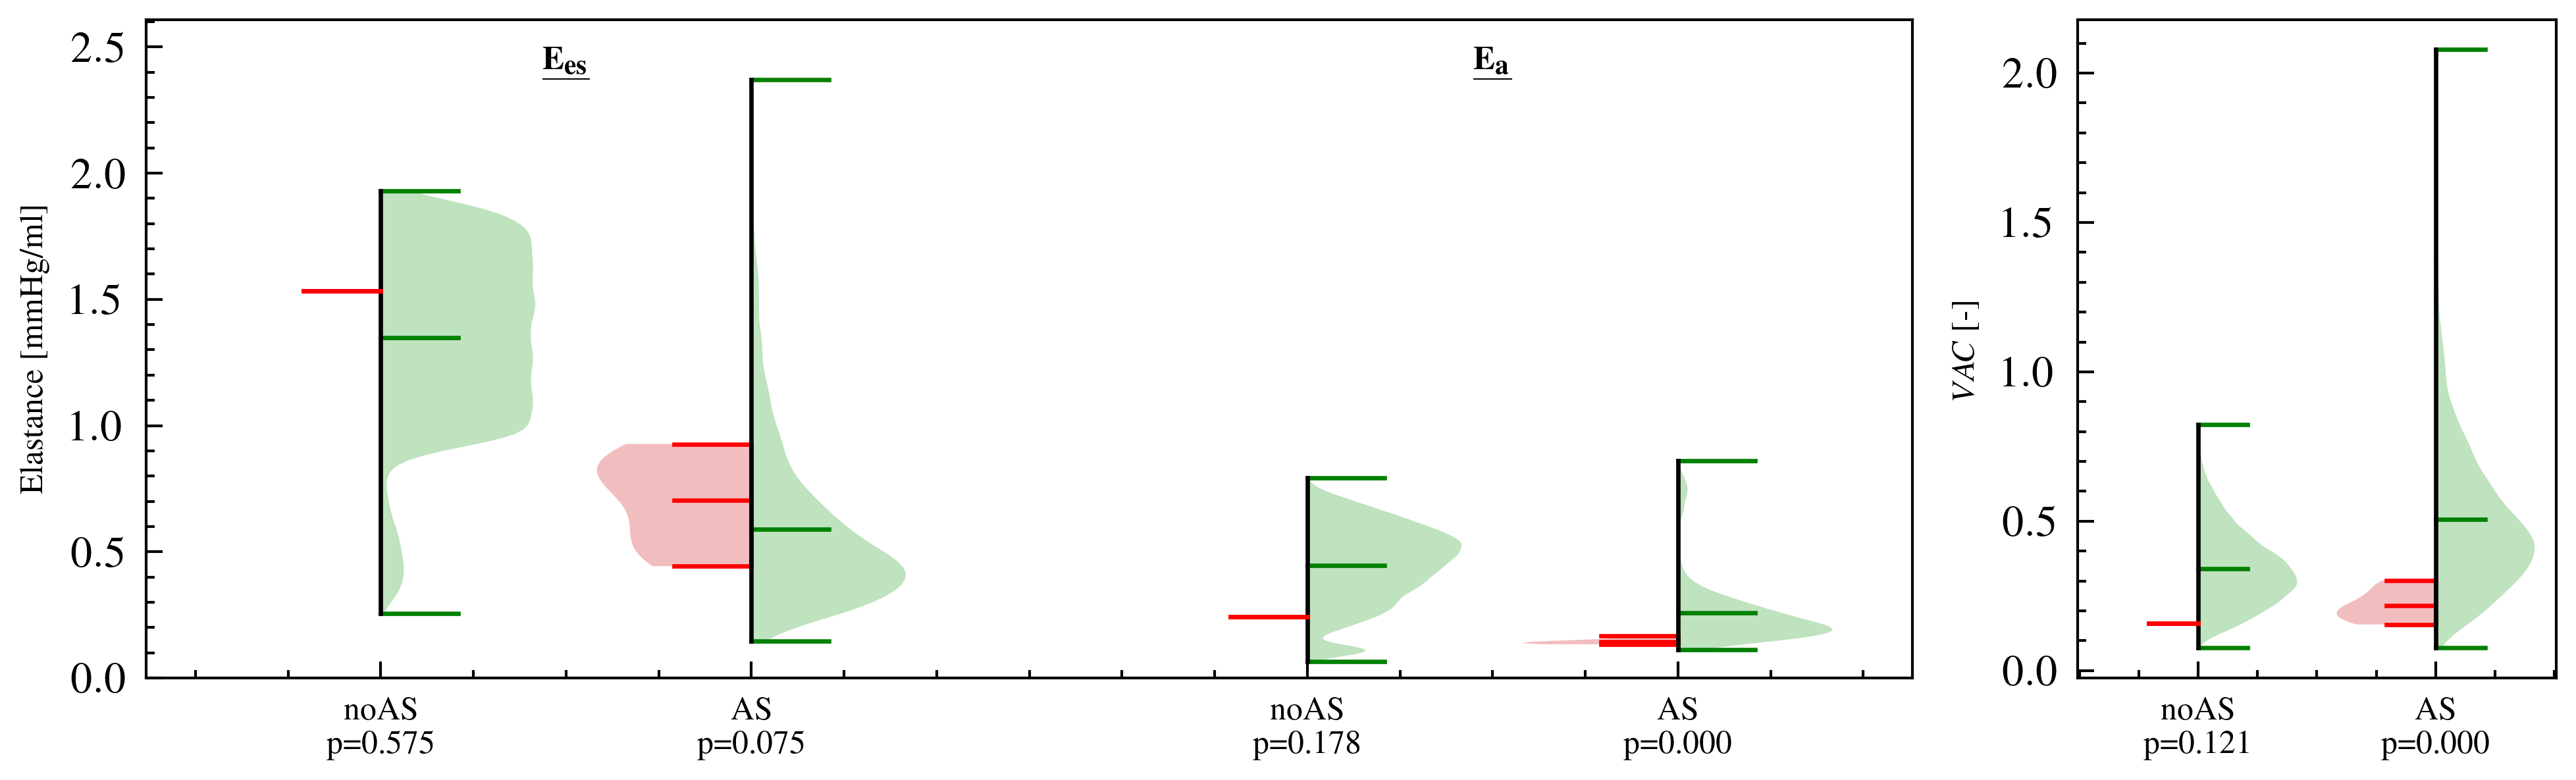

In [9]:
# simulation 4
input_df_noAS = input_sim4_noAS
input_df_AS = input_sim4_AS
output_df_noAS = output_sim4_noAS
output_df_AS = output_sim4_AS

imbalanced_IDs_noAS = output_df_noAS[output_df_noAS["DeltaE"]<0]["Patient_ID"].tolist()
input_df_balanced_noAS = input_df_noAS[~input_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
input_df_imbalanced_noAS = input_df_noAS[input_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
output_df_balanced_noAS = output_df_noAS[~output_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]
output_df_imbalanced_noAS = output_df_noAS[output_df_noAS["Patient_ID"].isin(imbalanced_IDs_noAS)]

imbalanced_IDs_AS = output_df_AS[output_df_AS["DeltaE"]<0]["Patient_ID"].tolist()
input_df_balanced_AS = input_df_AS[~input_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
input_df_imbalanced_AS = input_df_AS[input_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
output_df_balanced_AS = output_df_AS[~output_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]
output_df_imbalanced_AS = output_df_AS[output_df_AS["Patient_ID"].isin(imbalanced_IDs_AS)]

CENTIMETERS = 1/2.54
COLOR_BALANCED = "#2ca02c"
COLOR_IMBALANCE = "#d62728"

fig = plt.figure(figsize=(20*CENTIMETERS, 5.5*1*CENTIMETERS))

gs = fig.add_gridspec(1, 12, wspace=3.3, hspace=0.15)

axs = []
axs.append(fig.add_subplot(gs[0, 0:9]))
axs.append(fig.add_subplot(gs[0, 9:12]))




ax = axs[0]
keys = ["Ees_lv", "Ea_lv"]
keys_labels = [
    r"$\underline{\mathbf{E_{es}}}$", 
    r"$\underline{\mathbf{E_{a}}}$"
]
x_vp1, x_vp2 = 0, 0.6
x_ticks = []
x_ticks_labels = []
ymax = max([max(output_df_noAS[key].max(), output_df_AS[key].max()) for key in keys])
ymin = min([min(output_df_noAS[key].min(), output_df_AS[key].min()) for key in keys])
for key, key_label in zip(keys, keys_labels):
    data_plot = [output_df_balanced_noAS[key].values, output_df_balanced_AS[key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
    vp["bodies"][0].set_facecolor(COLOR_BALANCED)
    vp["bodies"][1].set_facecolor(COLOR_BALANCED)
    vp["cbars"].set_color("black")
    u, p_value_noAS = mannwhitneyu(output_df_balanced_noAS[key], output_df_imbalanced_noAS[key], method="asymptotic")
    r_noAS = 1 - 2*u / (len(output_df_balanced_noAS[key])*len(output_df_imbalanced_noAS[key]))
    r_noAS = np.round(r_noAS,2)

    data_plot = [output_df_imbalanced_noAS[key].values, output_df_imbalanced_AS[key].values]
    vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
    for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
    vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
    vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
    vp["cbars"].set_color("black")
    u, p_value_AS = mannwhitneyu(output_df_balanced_AS[key], output_df_imbalanced_AS[key], method="asymptotic")
    r_AS = 1 - 2*u / (len(output_df_balanced_AS[key])*len(output_df_imbalanced_AS[key]))
    r_AS = np.round(r_AS,2)
    
    x_ticks.append(x_vp1)
    x_ticks.append(x_vp2)
    x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
    x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
    ax.set_ylabel("Elastance [mmHg/ml]", fontsize=6)

    ax.text(np.mean([x_vp1, x_vp2]), ymax, f"{key_label}", ha='center', va='bottom', fontsize=6)

    x_vp1 += 1.5
    x_vp2 += 1.5

ax.set_ylim(0, ymax*1.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)

ax = axs[1]
key = "VAC_lv"
key_label = r"$VAC$"
x_vp1, x_vp2 = 0, 0.6
x_ticks_labels = []
x_ticks = []
data_plot = [output_df_balanced_noAS[key].values, output_df_balanced_AS[key].values]
vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="high")
for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("green")
vp["bodies"][0].set_facecolor(COLOR_BALANCED)
vp["bodies"][1].set_facecolor(COLOR_BALANCED)
vp["cbars"].set_color("black")
u, p_value_noAS = mannwhitneyu(output_df_balanced_noAS[key], output_df_imbalanced_noAS[key], method="asymptotic")
r_noAS = 1 - 2*u / (len(output_df_balanced_noAS[key])*len(output_df_imbalanced_noAS[key]))
r_noAS = np.round(r_noAS,2)

data_plot = [output_df_imbalanced_noAS[key].values, output_df_imbalanced_AS[key].values]
vp = ax.violinplot(data_plot, positions=[x_vp1, x_vp2], showmeans=True, side="low")
for part in ["cbars","cmins","cmaxes","cmeans"]: vp[part].set_color("red")
vp["bodies"][0].set_facecolor(COLOR_IMBALANCE)
vp["bodies"][1].set_facecolor(COLOR_IMBALANCE)
vp["cbars"].set_color("black")
u, p_value_AS = mannwhitneyu(output_df_balanced_AS[key], output_df_imbalanced_AS[key], method="asymptotic")
r_AS = 1 - 2*u / (len(output_df_balanced_AS[key])*len(output_df_imbalanced_AS[key]))
r_AS = np.round(r_AS,2)

x_ticks.append(x_vp1)
x_ticks.append(x_vp2)
x_ticks_labels.append(f"noAS\np={p_value_noAS:.3f}")
x_ticks_labels.append(f"AS\np={p_value_AS:.3f}")
ax.set_ylabel(r"$VAC$ [-]", fontsize=6)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontsize=6)


#plt.savefig("obrázky/VAC_sim4.svg")
plt.savefig("Figures/VAC_sim4.png", dpi=400)


plt.show()
